DATASET LOADING AND PREPROCESSING

Loading MoE System
Expert 1 (URL): Loaded
Expert 2 (Text): Loaded
Gating Network: Loaded

MoE System Ready!

Comprehensive Comparative Analysis with Real Data
STARTING COMPREHENSIVE COMPARATIVE ANALYSIS

Loading URL dataset from: C:\Users\angelo\Downloads\THESIS\Dataset_5971\url_dataset_combined_1.csv
Loading text dataset from: C:\Users\angelo\Downloads\THESIS\Dataset_5971\Dataset_100k.csv
✓ URL dataset loaded successfully: 722802 rows
  Trying encoding: utf-8
  ✗ Failed with utf-8: 'utf-8' codec can't decode byte 0xa0 in position 4...
  Trying encoding: latin-1
  ✓ Success with latin-1 encoding
✓ Text dataset loaded successfully: 150355 rows

Cleaning datasets...

URL dataset shape: (722802, 3)
Text dataset shape: (150355, 3)
✓ Combined dataset: 873157 samples
✓ Label distribution:
label
0    566061
1    307096
Name: count, dtype: int64

Sampling 20000 samples for faster processing...
✓ Sampled dataset: 20000 samples

Splitting dataset...
✓ Training 

MoE Prediction: 100%|██████████████████████████████████████████████████████████████| 4000/4000 [00:40<00:00, 97.77it/s]



Training and testing baseline models on real data...
Extracting comprehensive features from dataset...


Extracting features: 100%|████████████████████████████████████████████████████| 16000/16000 [00:01<00:00, 13887.47it/s]


Extracting comprehensive features from dataset...


Training models: 100%|███████████████████████████████████████████████████████████████████| 6/6 [02:21<00:00, 23.56s/it]



Run 5-fold cross-validation? (y/n):  y



Running 5-fold cross-validation...
Extracting comprehensive features from dataset...


Cross-validation: 100%|██████████████████████████████████████████████████████████████████| 4/4 [00:50<00:00, 12.53s/it]



Generating comparison plots...
✓ Saved performance_comparison.png


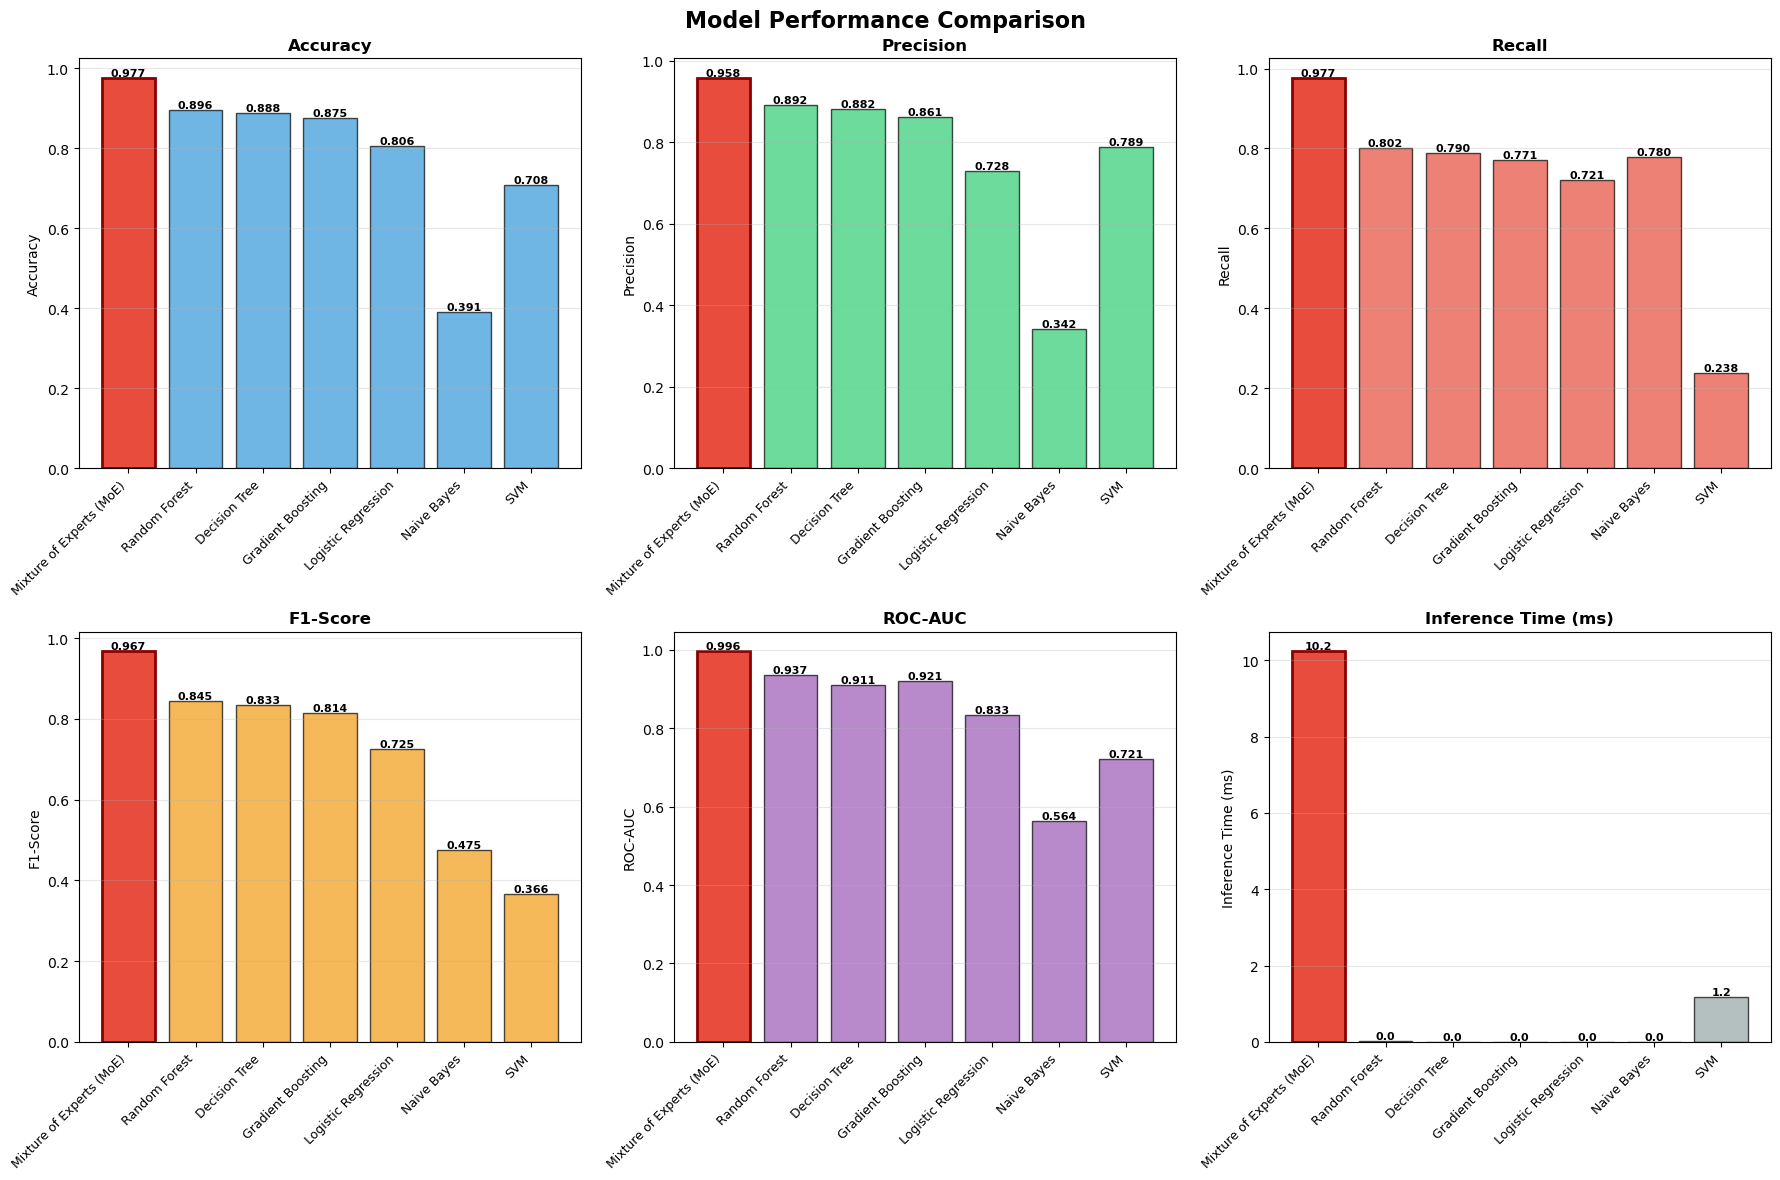

✓ Saved confusion_matrices.png


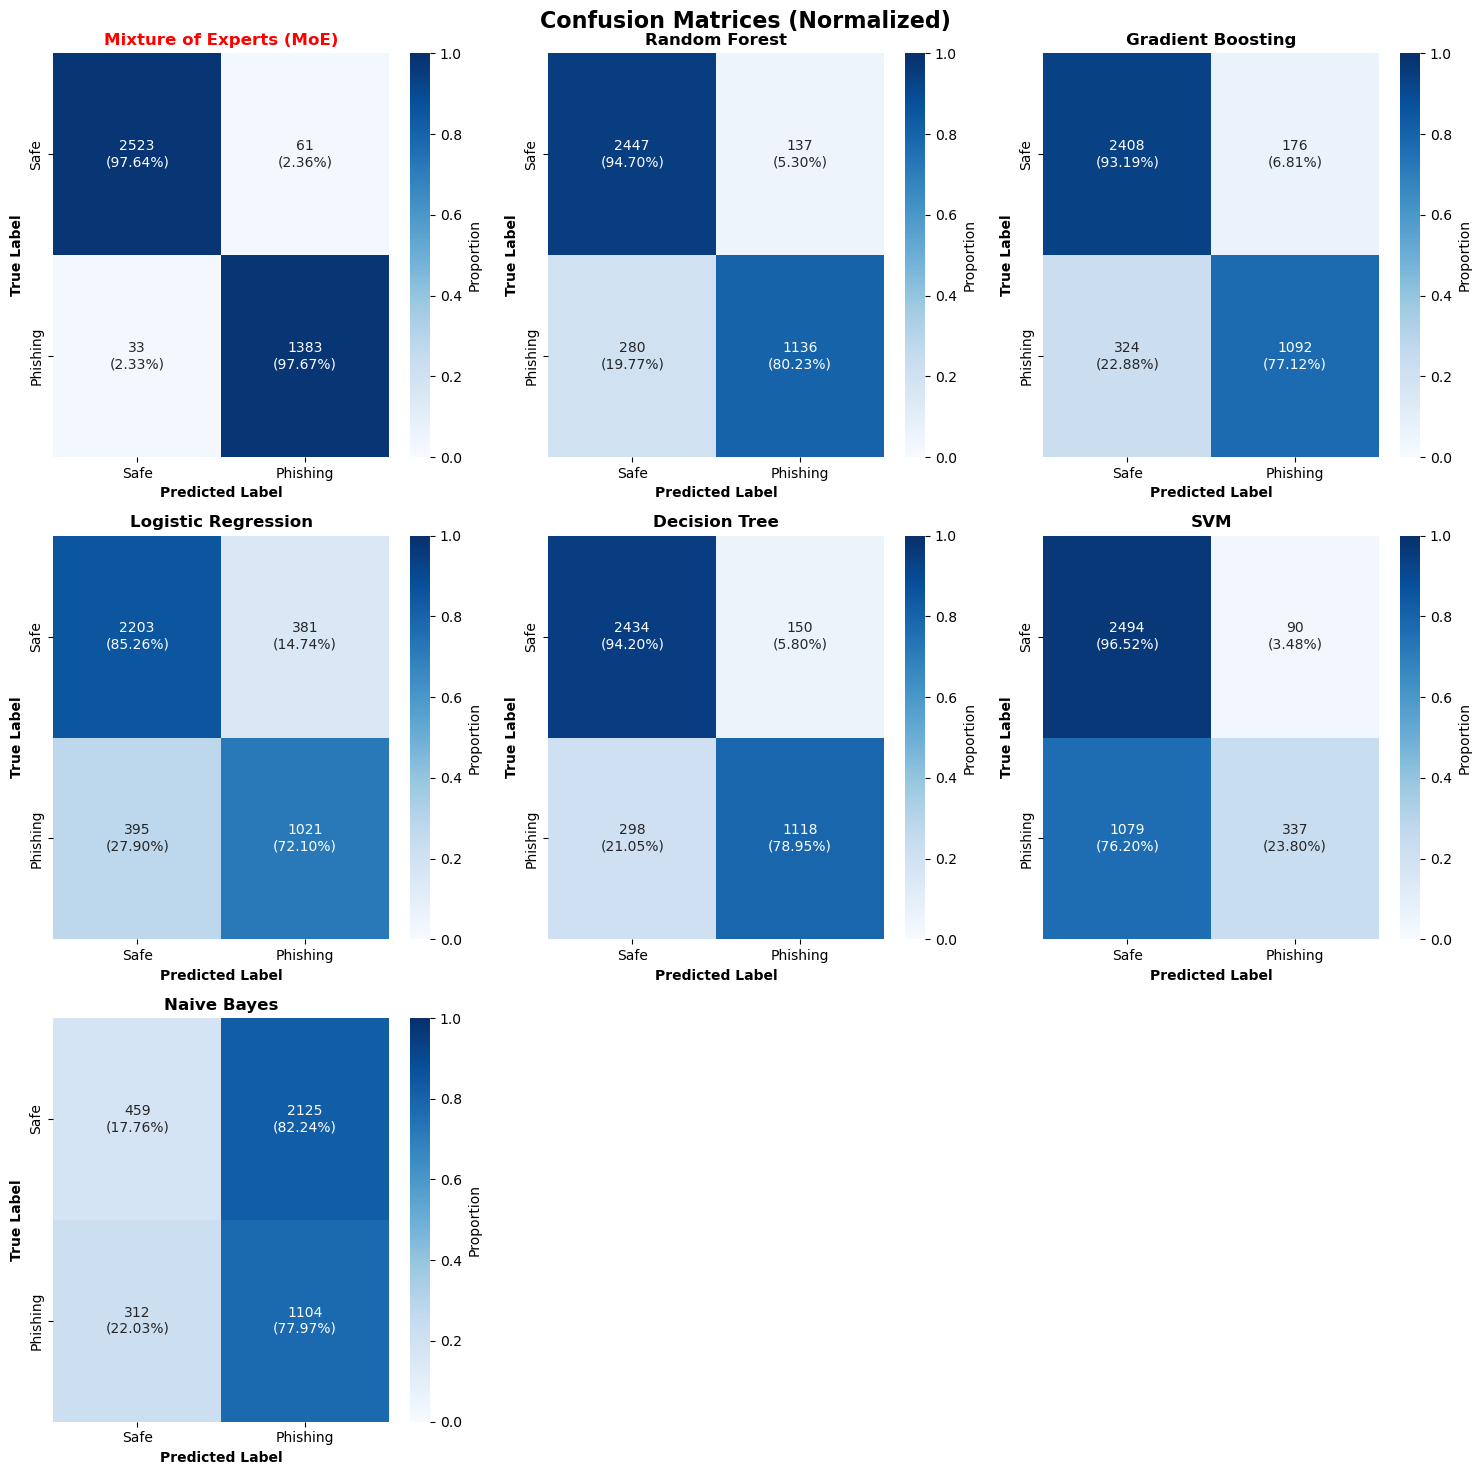

✓ Saved roc_curves.png


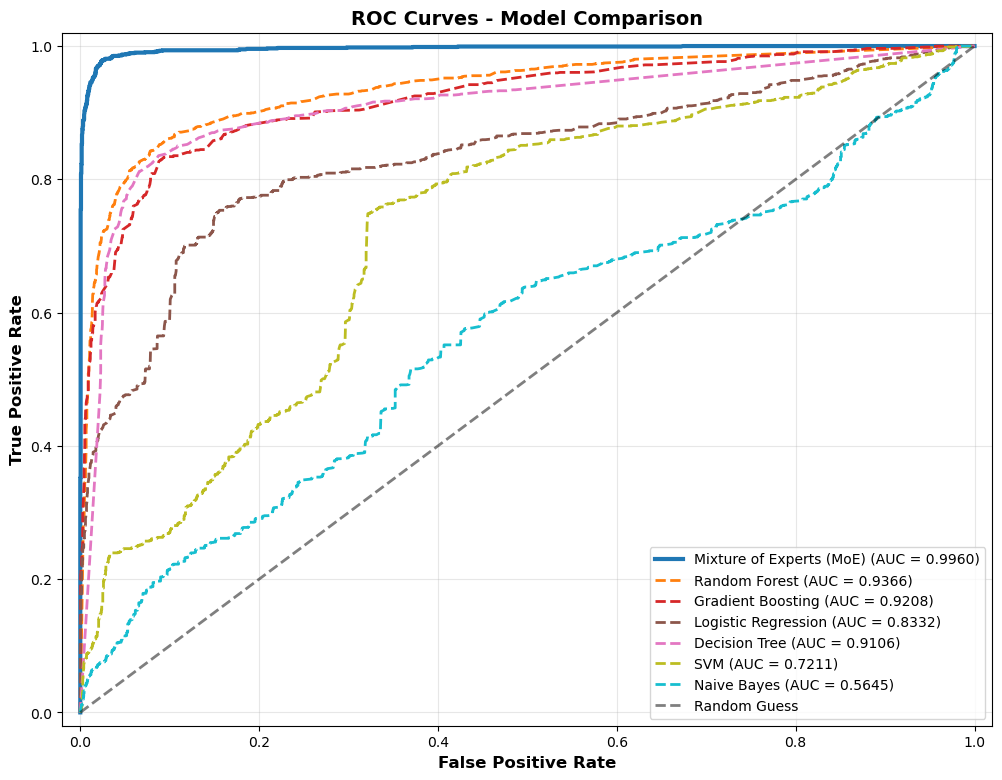

✓ Saved f1_score_ranking.png


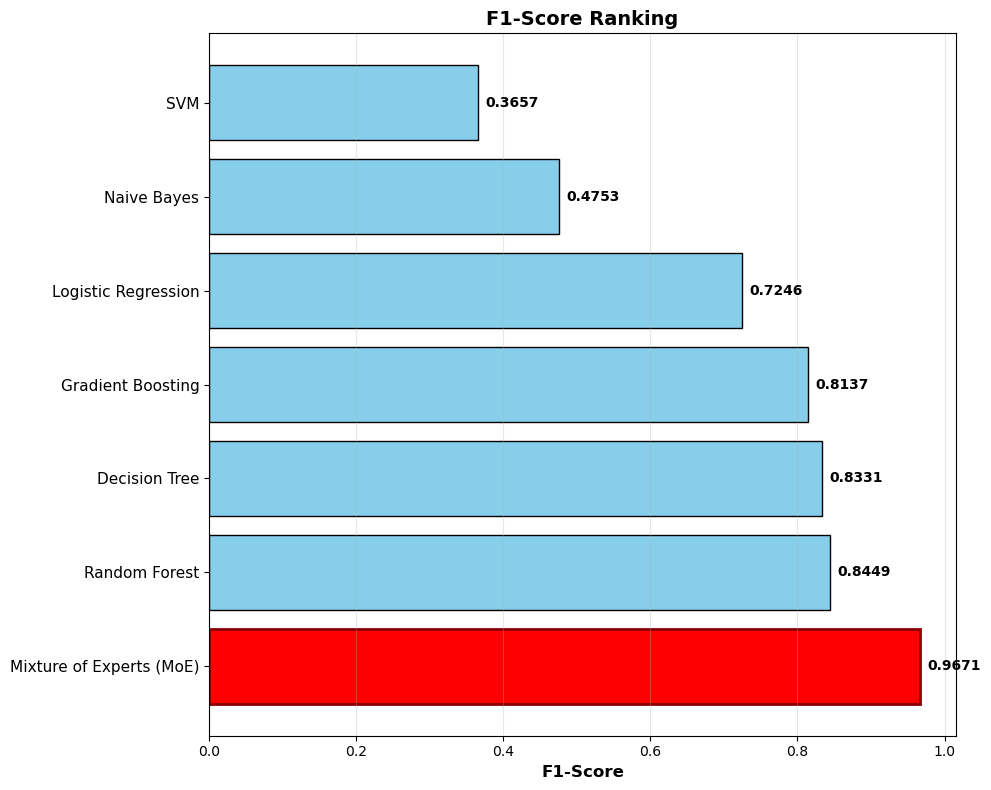

✓ Saved precision_recall_scatter.png


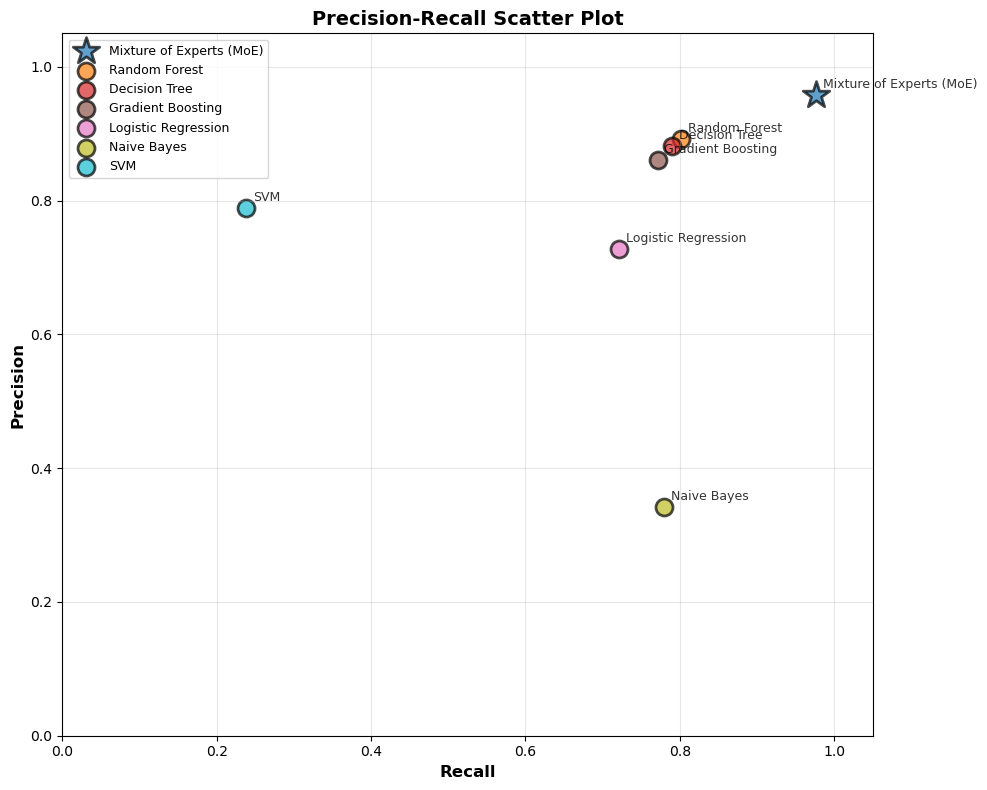

✓ Saved performance_radar.png


<Figure size 1200x1000 with 0 Axes>

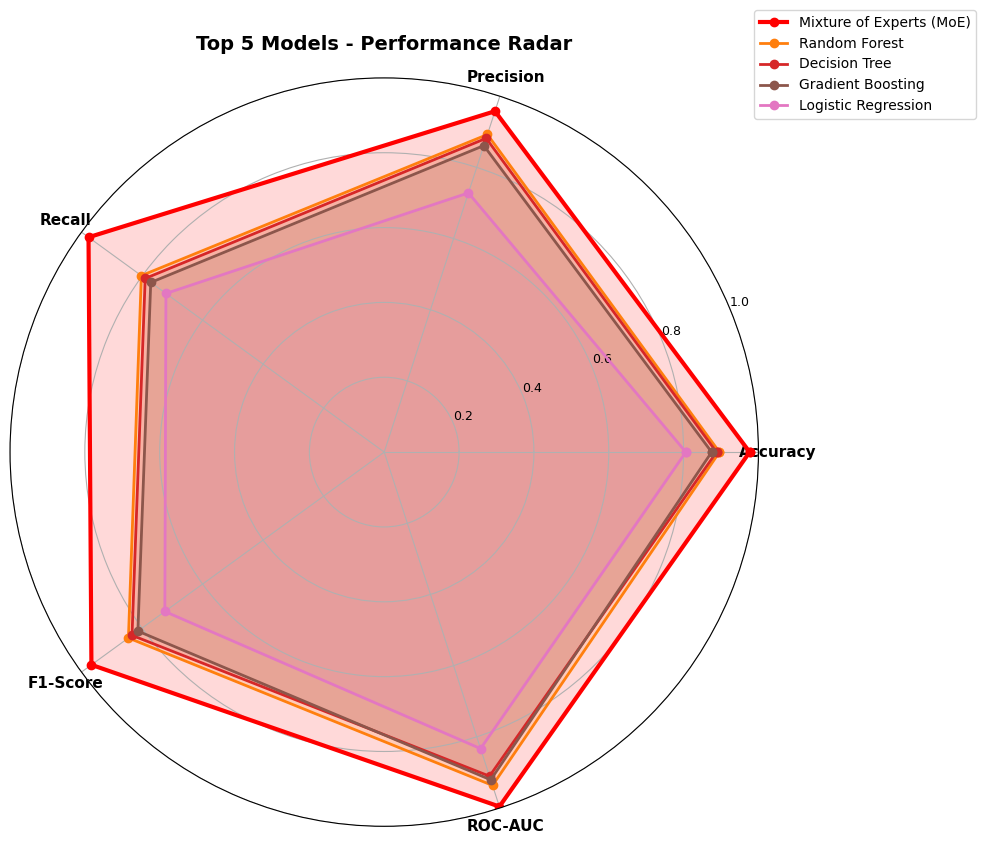

✓ Saved inference_time_comparison.png


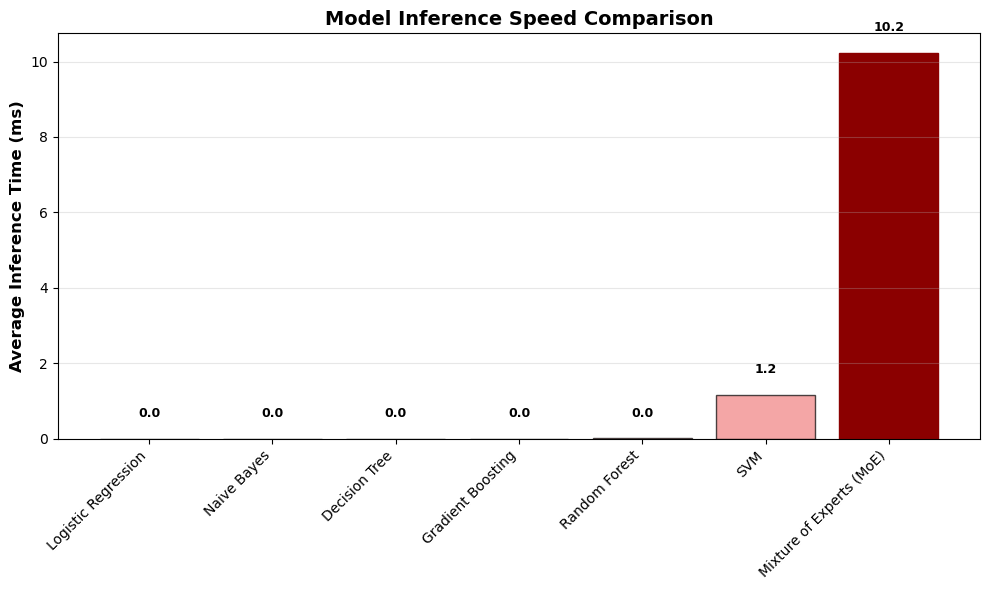

✓ Saved moe_expert_weights.png


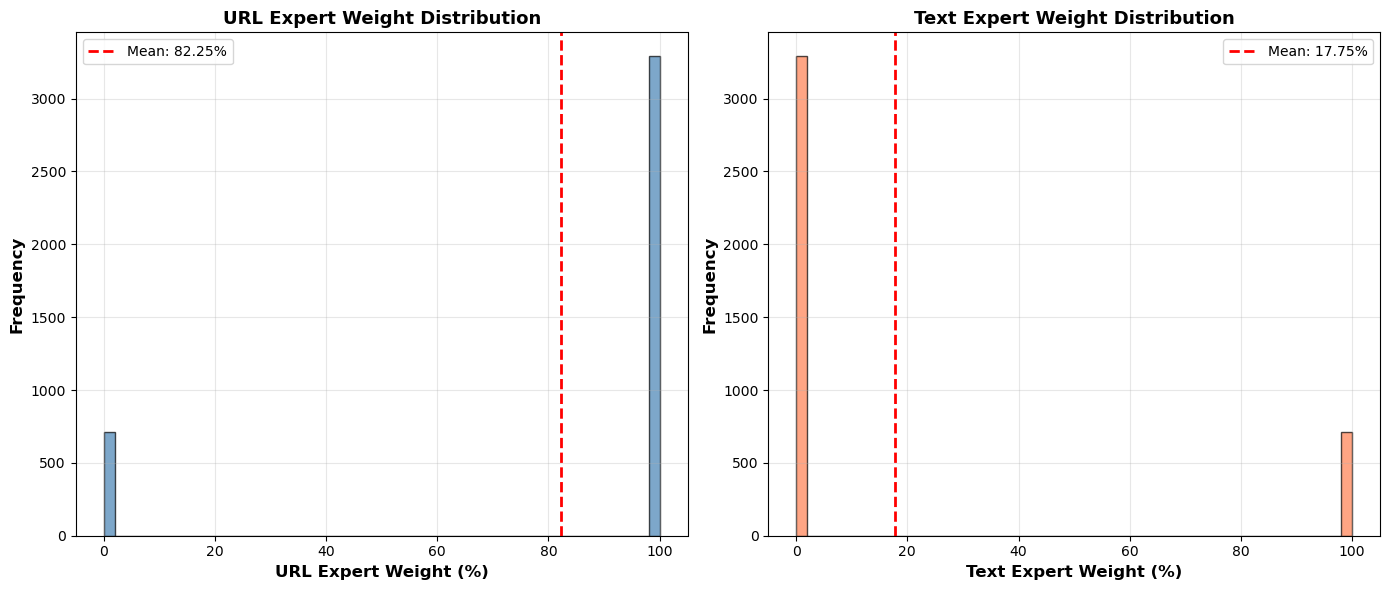

✓ Saved performance_heatmap.png


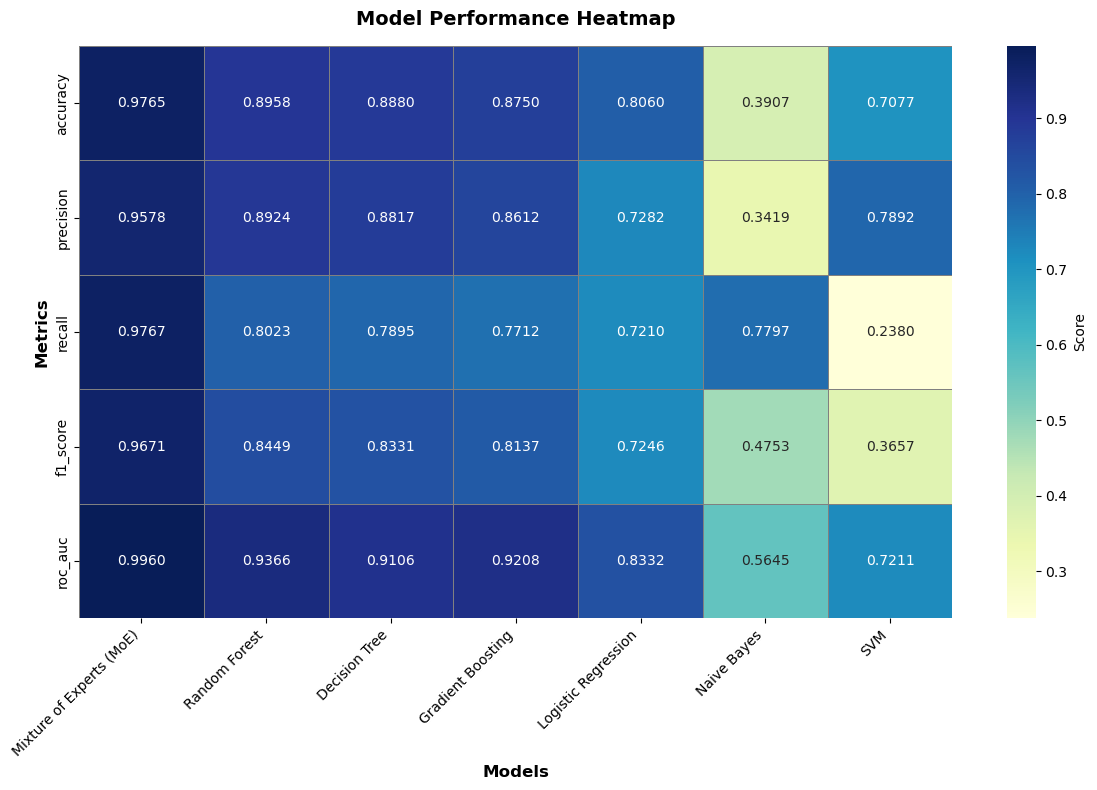


Saving detailed results...
✓ Saved detailed results to files
  - comparative_results_detailed.csv
  - moe_detailed_predictions.csv
  - analysis_summary.txt
  - performance_comparison.png
  - confusion_matrices.png
  - roc_curves.png

ANALYSIS COMPLETE - KEY FINDINGS

📊 MoE System Ranking: 1 out of 7 models

 MoE Performance Summary:
   F1-Score:  0.9671
   Accuracy:  0.9765
   Precision: 0.9578
   Recall:    0.9767
   ROC-AUC:   0.9960
   Avg Time:  10.23 ms

 Top 3 Models:
   1. Mixture of Experts (MoE): F1=0.9671, Acc=0.9765
   2. Random Forest: F1=0.8449, Acc=0.8958
   3. Decision Tree: F1=0.8331, Acc=0.8880

 Results saved to multiple files:
   - comparative_results_detailed.csv
   - moe_detailed_predictions.csv
   - analysis_summary.txt
   - Performance plots:
     • performance_comparison.png (6 metrics)
     • confusion_matrices.png (all models)
     • roc_curves.png (ROC comparison)
     • f1_score_ranking.png (horizontal bar)
     • precision_recall_scatter.png (scatter plot)

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import joblib
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import csr_matrix
import re
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import seaborn as sns
from tqdm import tqdm

# CRITICAL FIX: Enable inline plotting for Jupyter Notebook
%matplotlib inline
plt.style.use('default')  # Use default matplotlib style

# ============================================================================
# DATASET LOADING AND PREPROCESSING
# ============================================================================

print("=" * 70)
print("DATASET LOADING AND PREPROCESSING")
print("=" * 70)

def load_datasets_with_robust_processing(url_path, text_path, sample_size=20000):
    """
    Robust dataset loading with better error handling and preprocessing
    """
    print(f"Loading URL dataset from: {url_path}")
    print(f"Loading text dataset from: {text_path}")
    
    # ===== 1. Load URL dataset =====
    try:
        df_url = pd.read_csv(url_path)
        print(f"✓ URL dataset loaded successfully: {len(df_url)} rows")
    except Exception as e:
        print(f"✗ Error loading URL dataset: {e}")
        raise
    
    # Handle missing columns gracefully
    required_url_cols = ['url', 'label']
    available_url_cols = [col for col in required_url_cols if col in df_url.columns]
    
    if len(available_url_cols) < 2:
        print(f"Warning: URL dataset missing columns. Available: {df_url.columns.tolist()}")
        if 'url' in df_url.columns or 'URL' in df_url.columns:
            url_col = 'url' if 'url' in df_url.columns else 'URL'
            if 'label' in df_url.columns:
                df_url = df_url[[url_col, 'label']].copy()
                df_url.rename(columns={url_col: 'url'}, inplace=True)
            elif 'phishing' in df_url.columns:
                df_url = df_url[[url_col, 'phishing']].copy()
                df_url.rename(columns={url_col: 'url', 'phishing': 'label'}, inplace=True)
            elif 'target' in df_url.columns:
                df_url = df_url[[url_col, 'target']].copy()
                df_url.rename(columns={url_col: 'url', 'target': 'label'}, inplace=True)
        else:
            raise ValueError(f"Cannot find required columns in URL dataset. Available: {df_url.columns.tolist()}")
    else:
        df_url = df_url[required_url_cols].copy()
    
    df_url['text'] = ""
    
    # ===== 2. Load text dataset =====
    df_text = None
    encodings_to_try = ['utf-8', 'latin-1', 'ISO-8859-1', 'cp1252', 'utf-16']
    
    for encoding in encodings_to_try:
        try:
            print(f"  Trying encoding: {encoding}")
            df_text = pd.read_csv(text_path, encoding=encoding, on_bad_lines='skip')
            print(f"  ✓ Success with {encoding} encoding")
            break
        except Exception as e:
            print(f"  ✗ Failed with {encoding}: {str(e)[:50]}...")
            continue
    
    if df_text is None:
        raise ValueError(f"Could not load text dataset with any encoding. Tried: {encodings_to_try}")
    
    print(f"✓ Text dataset loaded successfully: {len(df_text)} rows")
    
    # Handle missing columns in text dataset
    text_col = None
    label_col = None
    
    for col in df_text.columns:
        col_lower = col.lower()
        if 'text' in col_lower or 'content' in col_lower or 'message' in col_lower:
            text_col = col
            break
    
    for col in df_text.columns:
        col_lower = col.lower()
        if 'label' in col_lower or 'class' in col_lower or 'target' in col_lower or 'phishing' in col_lower:
            label_col = col
            break
    
    if text_col and label_col:
        df_text = df_text[[text_col, label_col]].copy()
        df_text.rename(columns={text_col: 'text', label_col: 'label'}, inplace=True)
    elif all(col in df_text.columns for col in ['text', 'label']):
        df_text = df_text[['text', 'label']].copy()
    else:
        print(f"Warning: Text dataset columns: {df_text.columns.tolist()}")
        print("Assuming first column is text, second is label...")
        df_text = df_text.iloc[:, :2].copy()
        df_text.columns = ['text', 'label']
    
    df_text['url'] = ""
    
    # ===== 3. Data Cleaning =====
    print("\nCleaning datasets...")
    
    df_url['url'] = df_url['url'].astype(str).str.strip()
    df_url['text'] = df_url['text'].astype(str).str.strip()
    
    df_text['text'] = df_text['text'].astype(str).str.strip()
    df_text['url'] = df_text['url'].astype(str).str.strip()
    
    # ===== 4. Combine datasets =====
    print(f"\nURL dataset shape: {df_url.shape}")
    print(f"Text dataset shape: {df_text.shape}")
    
    df_combined = pd.concat([df_url, df_text], ignore_index=True)
    df_combined = df_combined.dropna(how='all')
    
    if df_combined['label'].dtype == object:
        df_combined['label'] = df_combined['label'].map({'safe': 0, 'phishing': 1, '0': 0, '1': 1, 
                                                         'benign': 0, 'malicious': 1, 'legitimate': 0})
    
    df_combined['label'] = pd.to_numeric(df_combined['label'], errors='coerce').fillna(0).astype(int)
    df_combined = df_combined[~((df_combined['text'].isna() | (df_combined['text'] == '')) & 
                               (df_combined['url'].isna() | (df_combined['url'] == '')))]
    
    print(f"✓ Combined dataset: {len(df_combined)} samples")
    print(f"✓ Label distribution:\n{df_combined['label'].value_counts()}")
    
    # ===== 5. Sampling =====
    if sample_size and len(df_combined) > sample_size:
        print(f"\nSampling {sample_size} samples for faster processing...")
        df_combined = df_combined.sample(n=sample_size, random_state=42, replace=False)
        print(f"✓ Sampled dataset: {len(df_combined)} samples")
    
    # ===== 6. Split into train and test =====
    print("\nSplitting dataset...")
    X = df_combined[['text', 'url']]
    y = df_combined['label']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    print(f"✓ Training set: {len(X_train)} samples")
    print(f"✓ Test set: {len(X_test)} samples")
    
    return df_combined, X_train, X_test, y_train, y_test

# ============================================================================
# LOAD MOE SYSTEM
# ============================================================================

print("\n" + "=" * 70)
print("Loading MoE System")
print("=" * 70)

class URLFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, urls):
        urls = np.array(urls).reshape(-1)
        feats = np.array([
            [len(u), u.count('-'), u.count('@'), u.count('?'), u.count('='), 
             u.count('.'), int(u.startswith("https")), int(u.count("//") > 1)]
            for u in urls
        ])
        return csr_matrix(feats)

class GatingNetwork(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_experts=2):
        super(GatingNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_experts)
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return self.softmax(x)

# Load models
URL_MODEL_PATH = r"C:\Users\angelo\Downloads\THESIS\URL_Expert-20251210T060216Z-1-001\URL_Expert\Notebook and Model\url_expert_1.pkl"
expert_1 = joblib.load(URL_MODEL_PATH)
print("Expert 1 (URL): Loaded")

TEXT_MODEL_PATH = r"C:\Users\angelo\Downloads\THESIS\distilbert_phishing_model"
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_PATH)
expert_2 = AutoModelForSequenceClassification.from_pretrained(TEXT_MODEL_PATH)
expert_2.eval()
print("Expert 2 (Text): Loaded")

gating_net = GatingNetwork(input_size=8, hidden_size=64, num_experts=2)
gating_net.load_state_dict(torch.load('gating_network.pth'))
gating_net.eval()
print("Gating Network: Loaded")

phrase_dict = {
    'urgent': 0.3, 'verify account': 0.5, 'suspended': 0.4, 'click here': 0.3,
    'confirm your': 0.4, 'congratulations': 0.3, 'winner': 0.4, 'limited time': 0.3,
    'act now': 0.3, 'security alert': 0.5, 'claim': 0.3, 'prize': 0.3, 'free': 0.2, 'bonus': 0.2,
}

def preprocess_text(text):
    if pd.isna(text) or text == "":
        return ""
    text = re.sub(r'http\S+', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def calculate_phrase_score(text, phrase_dict):
    if not text:
        return 0.0
    text_lower = text.lower()
    return min(sum(weight for phrase, weight in phrase_dict.items() if phrase in text_lower), 1.0)

def extract_gating_features(text, url, phrase_score):
    url_present = 1 if (url and not pd.isna(url) and url != "") else 0
    message_length = len(text.split()) if text else 0
    emoji_count = len(re.findall(r'[^\w\s,]', text)) if text else 0
    hashtag_count = text.count('#') if text else 0
    url_count = len(re.findall(r'http\S+', text)) if text else 0
    capital_ratio = sum(1 for c in text if c.isupper()) / len(text) if text else 0.0
    
    return np.array([url_present, phrase_score, message_length, emoji_count, 
                     hashtag_count, url_count, capital_ratio, 0.0], dtype=np.float32)

def predict_with_trained_model(text, url):
    text = preprocess_text(text)
    phrase_score = calculate_phrase_score(text, phrase_dict)
    
    if url and url.strip():
        try:
            url_probs = expert_1.predict_proba(pd.DataFrame({'url': [url]}))[0]
        except:
            url_probs = np.array([0.5, 0.5])
    else:
        url_probs = np.array([0.5, 0.5])
    
    if text:
        try:
            inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=128)
            with torch.no_grad():
                text_probs = torch.softmax(expert_2(**inputs).logits, dim=1)[0].numpy()
        except:
            text_probs = np.array([0.5, 0.5])
    else:
        text_probs = np.array([0.5, 0.5])
    
    gating_features = extract_gating_features(text, url, phrase_score)
    with torch.no_grad():
        expert_weights = gating_net(torch.FloatTensor(gating_features).unsqueeze(0))
    
    final_probs = expert_weights[0, 0].item() * url_probs + expert_weights[0, 1].item() * text_probs
    
    return {
        'prediction': "PHISHING" if final_probs[1] > 0.5 else "SAFE",
        'confidence': max(final_probs) * 100,
        'url_weight': expert_weights[0, 0].item() * 100,
        'text_weight': expert_weights[0, 1].item() * 100,
        'phishing_probability': final_probs[1] * 100
    }

print("\nMoE System Ready!\n")

# ============================================================================
# COMPREHENSIVE COMPARATIVE ANALYSIS WITH REAL DATA
# ============================================================================

print("=" * 70)
print("Comprehensive Comparative Analysis with Real Data")
print("=" * 70)

def extract_comprehensive_features(df):
    """
    Extract features for baseline models from the actual dataset
    """
    print("Extracting comprehensive features from dataset...")
    features = []
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
        text = str(row['text']) if pd.notna(row['text']) else ""
        url = str(row['url']) if pd.notna(row['url']) else ""
        
        # Text features
        text_len = len(text)
        word_count = len(text.split())
        exclamation_count = text.count('!')
        question_count = text.count('?')
        uppercase_ratio = sum(1 for c in text if c.isupper()) / max(len(text), 1)
        
        # Phishing indicator words
        phishing_indicators = ['urgent', 'click', 'verify', 'prize', 'winner', 'suspended', 
                              'security', 'alert', 'confirm', 'account', 'free', 'bonus']
        indicator_counts = [int(indicator in text.lower()) for indicator in phishing_indicators]
        
        # URL features
        url_present = int(bool(url))
        url_len = len(url) if url else 0
        url_dot_count = url.count('.') if url else 0
        url_hyphen_count = url.count('-') if url else 0
        url_at_count = url.count('@') if url else 0
        url_https = int(url.startswith('https')) if url else 0
        url_http = int(url.startswith('http')) if url else 0
        url_special_chars = sum(url.count(c) for c in ['=', '?', '&', '%']) if url else 0
        
        # Combine all features
        feature_vector = [text_len, word_count, exclamation_count, question_count, uppercase_ratio]
        feature_vector.extend(indicator_counts)
        feature_vector.extend([url_present, url_len, url_dot_count, url_hyphen_count, 
                              url_at_count, url_https, url_http, url_special_chars])
        
        features.append(feature_vector)
    
    return np.array(features)

# FIXED: Return y_test subset along with results
def test_moe_system_on_real_data(X_test, y_test, sample_size=None):
    """
    Test MoE system on real test data
    FIXED: Now properly handles sample_size and returns corresponding y_test
    """
    # Use all test data if sample_size not specified or larger than test set
    if sample_size is None or sample_size >= len(X_test):
        X_test_sample = X_test.copy()
        y_test_sample = y_test.copy()
        actual_sample_size = len(X_test)
    else:
        indices = np.random.choice(len(X_test), sample_size, replace=False)
        X_test_sample = X_test.iloc[indices].reset_index(drop=True)
        y_test_sample = y_test.iloc[indices].reset_index(drop=True)
        actual_sample_size = sample_size
    
    print(f"\nTesting MoE System on {actual_sample_size} real samples...")
    
    predictions = []
    phishing_probs = []
    url_weights = []
    text_weights = []
    inference_times = []
    
    start_total = time.time()
    
    for idx, row in tqdm(X_test_sample.iterrows(), total=len(X_test_sample), desc="MoE Prediction"):
        start_time = time.time()
        
        result = predict_with_trained_model(
            row['text'] if pd.notna(row['text']) else "",
            row['url'] if pd.notna(row['url']) else ""
        )
        
        inference_time = time.time() - start_time
        inference_times.append(inference_time)
        
        predictions.append(1 if result['prediction'] == 'PHISHING' else 0)
        phishing_probs.append(result['phishing_probability'])
        url_weights.append(result['url_weight'])
        text_weights.append(result['text_weight'])
    
    total_time = time.time() - start_total
    
    y_pred = np.array(predictions)
    y_true = y_test_sample.values
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    try:
        roc_auc = roc_auc_score(y_true, phishing_probs)
    except:
        roc_auc = 0.0
    
    cm = confusion_matrix(y_true, y_pred)
    
    return {
        'model_name': 'Mixture of Experts (MoE)',
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'inference_time': total_time,
        'avg_time_ms': (total_time / len(X_test_sample)) * 1000,
        'samples_tested': len(X_test_sample),
        'confusion_matrix': cm,
        'phishing_probabilities': phishing_probs,
        'url_weights': url_weights,
        'text_weights': text_weights,
        'predictions': y_pred,
        'y_true': y_true  # FIXED: Include y_true for proper ROC plotting
    }

def train_and_test_baseline_models(X_train, y_train, X_test, y_test):
    """
    Train and test baseline models on real data
    """
    print("\nTraining and testing baseline models on real data...")
    
    # Extract features
    X_train_features = extract_comprehensive_features(X_train)
    X_test_features = extract_comprehensive_features(X_test)
    
    algorithms = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42, probability=True),
        'Naive Bayes': MultinomialNB()
    }
    
    results = {}
    
    for name, model in tqdm(algorithms.items(), desc="Training models"):
        try:
            train_start = time.time()
            model.fit(X_train_features, y_train)
            train_time = time.time() - train_start
            
            test_start = time.time()
            
            if hasattr(model, 'predict_proba'):
                y_pred_proba = model.predict_proba(X_test_features)[:, 1]
                y_pred = (y_pred_proba > 0.5).astype(int)
            else:
                y_pred = model.predict(X_test_features)
                y_pred_proba = y_pred
            
            test_time = time.time() - test_start
            
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            
            try:
                roc_auc = roc_auc_score(y_test, y_pred_proba)
            except:
                roc_auc = 0.0
            
            cm = confusion_matrix(y_test, y_pred)
            
            results[name] = {
                'model_name': name,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'roc_auc': roc_auc,
                'training_time': train_time,
                'inference_time': test_time,
                'avg_time_ms': (test_time / len(X_test)) * 1000,
                'confusion_matrix': cm,
                'predictions': y_pred,
                'probabilities': y_pred_proba if hasattr(model, 'predict_proba') else None,
                'y_true': y_test.values  # FIXED: Include y_true
            }
            
        except Exception as e:
            print(f"\nWarning: {name} failed with error: {str(e)[:100]}")
            continue
    
    return results

def run_cross_validation_analysis(X, y, cv_folds=5):
    """
    Run cross-validation for more robust comparison
    """
    print(f"\nRunning {cv_folds}-fold cross-validation...")
    
    X_features = extract_comprehensive_features(X)
    
    algorithms = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
    }
    
    cv_results = {}
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    for name, model in tqdm(algorithms.items(), desc="Cross-validation"):
        try:
            cv_accuracy = cross_val_score(model, X_features, y, cv=skf, scoring='accuracy', n_jobs=-1)
            cv_f1 = cross_val_score(model, X_features, y, cv=skf, scoring='f1', n_jobs=-1)
            cv_precision = cross_val_score(model, X_features, y, cv=skf, scoring='precision', n_jobs=-1)
            cv_recall = cross_val_score(model, X_features, y, cv=skf, scoring='recall', n_jobs=-1)
            
            cv_results[name] = {
                'cv_accuracy_mean': np.mean(cv_accuracy),
                'cv_accuracy_std': np.std(cv_accuracy),
                'cv_f1_mean': np.mean(cv_f1),
                'cv_f1_std': np.std(cv_f1),
                'cv_precision_mean': np.mean(cv_precision),
                'cv_precision_std': np.std(cv_precision),
                'cv_recall_mean': np.mean(cv_recall),
                'cv_recall_std': np.std(cv_recall)
            }
        except Exception as e:
            print(f"\nWarning: CV for {name} failed: {str(e)[:100]}")
            continue
    
    return cv_results

# FIXED: Proper handling of y_test for ROC curves
def plot_comparison_results(moe_results, baseline_results, cv_results=None):
    """
    Create comprehensive comparison plots
    FIXED: Use y_true from results instead of global y_test
    """
    print("\nGenerating comparison plots...")
    
    all_results = [moe_results] + list(baseline_results.values())
    comparison_df = pd.DataFrame(all_results)
    comparison_df = comparison_df.sort_values('f1_score', ascending=False)
    
    # 1. Performance Metrics Bar Plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    
    metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'avg_time_ms']
    titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Inference Time (ms)']
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#95a5a6']
    
    for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
        ax = axes[idx // 3, idx % 3]
        bars = ax.bar(range(len(comparison_df)), comparison_df[metric], color=color, alpha=0.7, edgecolor='black')
        
        # Highlight MoE in red
        for i, bar in enumerate(bars):
            if 'MoE' in comparison_df.iloc[i]['model_name']:
                bar.set_color('#e74c3c')
                bar.set_alpha(1.0)
                bar.set_edgecolor('darkred')
                bar.set_linewidth(2)
        
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_ylabel(title, fontsize=10)
        ax.set_xticks(range(len(comparison_df)))
        ax.set_xticklabels(comparison_df['model_name'], rotation=45, ha='right', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on top of bars
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}' if metric != 'avg_time_ms' else f'{height:.1f}',
                   ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Saved performance_comparison.png")
    plt.show()  # CRITICAL: Display in Jupyter
    
    # 2. Confusion Matrices
    n_models = len(all_results)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    fig.suptitle('Confusion Matrices (Normalized)', fontsize=16, fontweight='bold')
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()
    for idx, result in enumerate(all_results):
        if idx >= len(axes):
            break
            
        cm = result['confusion_matrix']
        ax = axes[idx]
        
        # Normalize confusion matrix
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Create annotations with both count and percentage
        annotations = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annotations[i, j] = f'{cm[i, j]}\n({cm_normalized[i, j]:.2%})'
        
        sns.heatmap(cm_normalized, annot=annotations, fmt='', cmap='Blues', 
                    xticklabels=['Safe', 'Phishing'], 
                    yticklabels=['Safe', 'Phishing'],
                    ax=ax, cbar_kws={'label': 'Proportion'}, vmin=0, vmax=1)
        
        title_color = 'red' if 'MoE' in result['model_name'] else 'black'
        ax.set_title(f"{result['model_name']}", fontweight='bold', color=title_color)
        ax.set_xlabel('Predicted Label', fontweight='bold')
        ax.set_ylabel('True Label', fontweight='bold')
    
    # Hide empty subplots
    for idx in range(len(all_results), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
    print("✓ Saved confusion_matrices.png")
    plt.show()  # CRITICAL: Display in Jupyter
    
    # 3. ROC Curves - FIXED VERSION
    plt.figure(figsize=(12, 9))
    
    colors_roc = plt.cm.tab10(np.linspace(0, 1, len(all_results)))
    
    for idx, result in enumerate(all_results):
        # Get probabilities and true labels from the result itself
        if 'phishing_probabilities' in result:  # MoE
            probs = np.array(result['phishing_probabilities']) / 100  # Convert from percentage
            y_true = result['y_true']
        elif result.get('probabilities') is not None:  # Baseline
            probs = result['probabilities']
            y_true = result['y_true']
        else:
            continue
        
        # Plot ROC curve
        fpr, tpr, _ = roc_curve(y_true, probs)
        roc_auc = result.get('roc_auc', roc_auc_score(y_true, probs))
        
        linewidth = 3 if 'MoE' in result['model_name'] else 2
        linestyle = '-' if 'MoE' in result['model_name'] else '--'
        
        plt.plot(fpr, tpr, label=f"{result['model_name']} (AUC = {roc_auc:.4f})",
                linewidth=linewidth, linestyle=linestyle, color=colors_roc[idx])
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=2, alpha=0.5)
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])
    plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
    print("✓ Saved roc_curves.png")
    plt.show()  # CRITICAL: Display in Jupyter
    
    # 4. F1-Score Comparison (Horizontal Bar Chart)
    plt.figure(figsize=(10, 8))
    y_pos = np.arange(len(comparison_df))
    
    bars = plt.barh(y_pos, comparison_df['f1_score'], color='skyblue', edgecolor='black')
    
    # Highlight MoE
    for i, (idx, row) in enumerate(comparison_df.iterrows()):
        if 'MoE' in row['model_name']:
            bars[i].set_color('red')
            bars[i].set_edgecolor('darkred')
            bars[i].set_linewidth(2)
    
    plt.yticks(y_pos, comparison_df['model_name'], fontsize=11)
    plt.xlabel('F1-Score', fontsize=12, fontweight='bold')
    plt.title('F1-Score Ranking', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, v in enumerate(comparison_df['f1_score']):
        plt.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('f1_score_ranking.png', dpi=300, bbox_inches='tight')
    print("✓ Saved f1_score_ranking.png")
    plt.show()  # CRITICAL: Display in Jupyter
    
    # 5. Precision-Recall Scatter Plot
    plt.figure(figsize=(10, 8))
    
    for idx, (_, row) in enumerate(comparison_df.iterrows()):
        marker = 'o' if 'MoE' not in row['model_name'] else '*'
        size = 150 if 'MoE' not in row['model_name'] else 400
        color = colors_roc[idx]
        
        plt.scatter(row['recall'], row['precision'], s=size, marker=marker,
                   color=color, alpha=0.7, edgecolor='black', linewidth=2,
                   label=row['model_name'])
        
        # Add model name annotations
        plt.annotate(row['model_name'], 
                    (row['recall'], row['precision']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, alpha=0.8)
    
    plt.xlabel('Recall', fontsize=12, fontweight='bold')
    plt.ylabel('Precision', fontsize=12, fontweight='bold')
    plt.title('Precision-Recall Scatter Plot', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1.05])
    plt.ylim([0, 1.05])
    plt.legend(loc='best', fontsize=9)
    plt.tight_layout()
    plt.savefig('precision_recall_scatter.png', dpi=300, bbox_inches='tight')
    print("✓ Saved precision_recall_scatter.png")
    plt.show()  # CRITICAL: Display in Jupyter
    
    # 6. Radar Chart for Top 5 Models
    plt.figure(figsize=(12, 10))
    
    top_5 = comparison_df.head(5)
    categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    num_vars = len(categories)
    
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    for idx, (_, row) in enumerate(top_5.iterrows()):
        values = [row['accuracy'], row['precision'], row['recall'], 
                 row['f1_score'], row['roc_auc']]
        values += values[:1]
        
        color = 'red' if 'MoE' in row['model_name'] else colors_roc[idx]
        linewidth = 3 if 'MoE' in row['model_name'] else 2
        
        ax.plot(angles, values, 'o-', linewidth=linewidth, label=row['model_name'], color=color)
        ax.fill(angles, values, alpha=0.15, color=color)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
    ax.grid(True)
    ax.set_title('Top 5 Models - Performance Radar', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    
    plt.tight_layout()
    plt.savefig('performance_radar.png', dpi=300, bbox_inches='tight')
    print("✓ Saved performance_radar.png")
    plt.show()  # CRITICAL: Display in Jupyter
    
    # 7. Inference Time Comparison
    plt.figure(figsize=(10, 6))
    
    sorted_by_time = comparison_df.sort_values('avg_time_ms')
    bars = plt.bar(range(len(sorted_by_time)), sorted_by_time['avg_time_ms'], 
                   color='lightcoral', edgecolor='black', alpha=0.7)
    
    # Highlight MoE
    for i, (idx, row) in enumerate(sorted_by_time.iterrows()):
        if 'MoE' in row['model_name']:
            bars[i].set_color('darkred')
            bars[i].set_alpha(1.0)
    
    plt.xticks(range(len(sorted_by_time)), sorted_by_time['model_name'], 
              rotation=45, ha='right', fontsize=10)
    plt.ylabel('Average Inference Time (ms)', fontsize=12, fontweight='bold')
    plt.title('Model Inference Speed Comparison', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, v in enumerate(sorted_by_time['avg_time_ms']):
        plt.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', 
                fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('inference_time_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Saved inference_time_comparison.png")
    plt.show()  # CRITICAL: Display in Jupyter
    
    # 8. MoE Expert Weights Distribution (if MoE exists)
    if 'url_weights' in moe_results and 'text_weights' in moe_results:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        
        # URL Expert Weights
        ax1.hist(moe_results['url_weights'], bins=50, color='steelblue', 
                edgecolor='black', alpha=0.7)
        ax1.set_xlabel('URL Expert Weight (%)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
        ax1.set_title('URL Expert Weight Distribution', fontsize=13, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.axvline(np.mean(moe_results['url_weights']), color='red', 
                   linestyle='--', linewidth=2, label=f'Mean: {np.mean(moe_results["url_weights"]):.2f}%')
        ax1.legend()
        
        # Text Expert Weights
        ax2.hist(moe_results['text_weights'], bins=50, color='coral', 
                edgecolor='black', alpha=0.7)
        ax2.set_xlabel('Text Expert Weight (%)', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
        ax2.set_title('Text Expert Weight Distribution', fontsize=13, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.axvline(np.mean(moe_results['text_weights']), color='red', 
                   linestyle='--', linewidth=2, label=f'Mean: {np.mean(moe_results["text_weights"]):.2f}%')
        ax2.legend()
        
        plt.tight_layout()
        plt.savefig('moe_expert_weights.png', dpi=300, bbox_inches='tight')
        print("✓ Saved moe_expert_weights.png")
        plt.show()  # CRITICAL: Display in Jupyter
    
    # 9. Model Performance Heatmap
    plt.figure(figsize=(12, 8))
    
    metrics_for_heatmap = comparison_df[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']].T
    metrics_for_heatmap.columns = comparison_df['model_name']
    
    sns.heatmap(metrics_for_heatmap, annot=True, fmt='.4f', cmap='YlGnBu', 
                cbar_kws={'label': 'Score'}, linewidths=0.5, linecolor='gray')
    plt.title('Model Performance Heatmap', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Metrics', fontsize=12, fontweight='bold')
    plt.xlabel('Models', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('performance_heatmap.png', dpi=300, bbox_inches='tight')
    print("✓ Saved performance_heatmap.png")
    plt.show()  # CRITICAL: Display in Jupyter
    
    # Don't close all at the end - let Jupyter display them
    # plt.close('all')  # REMOVED - this was preventing display
    
    return comparison_df

def save_detailed_results(moe_results, baseline_results, comparison_df, X_test, cv_results=None):
    """
    Save detailed results to files
    """
    print("\nSaving detailed results...")
    
    # Save comparison dataframe
    comparison_df.to_csv('comparative_results_detailed.csv', index=False)
    
    # Save MoE detailed predictions
    moe_sample_size = len(moe_results['predictions'])
    moe_details = pd.DataFrame({
        'text': X_test.iloc[:moe_sample_size]['text'].reset_index(drop=True),
        'url': X_test.iloc[:moe_sample_size]['url'].reset_index(drop=True),
        'true_label': moe_results['y_true'],
        'predicted_label': moe_results['predictions'],
        'phishing_probability': moe_results['phishing_probabilities'],
        'url_weight': moe_results['url_weights'],
        'text_weight': moe_results['text_weights']
    })
    moe_details.to_csv('moe_detailed_predictions.csv', index=False)
    
    # Save summary report
    with open('analysis_summary.txt', 'w') as f:
        f.write("=" * 70 + "\n")
        f.write("COMPREHENSIVE PHISHING DETECTION ANALYSIS REPORT\n")
        f.write("=" * 70 + "\n\n")
        
        f.write(f"Dataset Summary:\n")
        f.write(f"- Total samples tested: {len(baseline_results[list(baseline_results.keys())[0]]['y_true'])}\n")
        f.write(f"- MoE samples tested: {len(moe_results['y_true'])}\n")
        
        y_test_full = baseline_results[list(baseline_results.keys())[0]]['y_true']
        f.write(f"- Phishing samples: {(y_test_full == 1).sum()}\n")
        f.write(f"- Safe samples: {(y_test_full == 0).sum()}\n\n")
        
        f.write("=" * 70 + "\n")
        f.write("MODEL PERFORMANCE RANKING (by F1-Score)\n")
        f.write("=" * 70 + "\n\n")
        
        for i, (_, row) in enumerate(comparison_df.iterrows(), 1):
            f.write(f"{i}. {row['model_name']}:\n")
            f.write(f"   Accuracy:  {row['accuracy']:.4f}\n")
            f.write(f"   Precision: {row['precision']:.4f}\n")
            f.write(f"   Recall:    {row['recall']:.4f}\n")
            f.write(f"   F1-Score:  {row['f1_score']:.4f}\n")
            f.write(f"   ROC-AUC:   {row.get('roc_auc', 0):.4f}\n")
            f.write(f"   Avg Time:  {row['avg_time_ms']:.2f} ms\n")
            
            if 'confusion_matrix' in row:
                cm = row['confusion_matrix']
                f.write(f"   Confusion Matrix:\n")
                f.write(f"      [[{cm[0,0]:4d} {cm[0,1]:4d}]\n")
                f.write(f"       [{cm[1,0]:4d} {cm[1,1]:4d}]]\n")
            
            f.write("\n")
        
        if cv_results:
            f.write("=" * 70 + "\n")
            f.write("CROSS-VALIDATION RESULTS (5-fold)\n")
            f.write("=" * 70 + "\n\n")
            
            for name, cv_result in cv_results.items():
                f.write(f"{name}:\n")
                f.write(f"  Accuracy:  {cv_result['cv_accuracy_mean']:.4f} ± {cv_result['cv_accuracy_std']:.4f}\n")
                f.write(f"  F1-Score:  {cv_result['cv_f1_mean']:.4f} ± {cv_result['cv_f1_std']:.4f}\n")
                f.write(f"  Precision: {cv_result['cv_precision_mean']:.4f} ± {cv_result['cv_precision_std']:.4f}\n")
                f.write(f"  Recall:    {cv_result['cv_recall_mean']:.4f} ± {cv_result['cv_recall_std']:.4f}\n\n")
    
    print("✓ Saved detailed results to files")
    print("  - comparative_results_detailed.csv")
    print("  - moe_detailed_predictions.csv")
    print("  - analysis_summary.txt")
    print("  - performance_comparison.png")
    print("  - confusion_matrices.png")
    print("  - roc_curves.png")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    try:
        print("=" * 70)
        print("STARTING COMPREHENSIVE COMPARATIVE ANALYSIS")
        print("=" * 70 + "\n")
        
        # Load and preprocess datasets
        url_path = r"C:\Users\angelo\Downloads\THESIS\Dataset_5971\url_dataset_combined_1.csv"
        text_path = r"C:\Users\angelo\Downloads\THESIS\Dataset_5971\Dataset_100k.csv"
        
        df_combined, X_train, X_test, y_train, y_test = load_datasets_with_robust_processing(
            url_path, text_path, sample_size=20000
        )
        
        # FIXED: Test MoE on ALL test data (or specify consistent sample_size)
        # Option 1: Test on all data (recommended for fair comparison)
        moe_results = test_moe_system_on_real_data(X_test, y_test, sample_size=None)
        
        # Option 2: If you want to test on subset for speed, use same size for all
        # moe_results = test_moe_system_on_real_data(X_test, y_test, sample_size=1000)
        
        # Train and test baseline models
        baseline_results = train_and_test_baseline_models(X_train, y_train, X_test, y_test)
        
        # Optional: Run cross-validation
        run_cv = input("\nRun 5-fold cross-validation? (y/n): ").lower() == 'y'
        cv_results = None
        if run_cv:
            cv_results = run_cross_validation_analysis(
                pd.concat([X_train, X_test]), 
                pd.concat([y_train, y_test])
            )
        
        # Plot and save results
        comparison_df = plot_comparison_results(moe_results, baseline_results, cv_results)
        
        # Save detailed results
        save_detailed_results(moe_results, baseline_results, comparison_df, X_test, cv_results)
        
        # Display summary
        print("\n" + "=" * 70)
        print("ANALYSIS COMPLETE - KEY FINDINGS")
        print("=" * 70)
        
        moe_rank = comparison_df[comparison_df['model_name'].str.contains('MoE')].index[0] + 1
        print(f"\n📊 MoE System Ranking: {moe_rank} out of {len(comparison_df)} models")
        
        moe_row = comparison_df[comparison_df['model_name'].str.contains('MoE')].iloc[0]
        print(f"\n MoE Performance Summary:")
        print(f"   F1-Score:  {moe_row['f1_score']:.4f}")
        print(f"   Accuracy:  {moe_row['accuracy']:.4f}")
        print(f"   Precision: {moe_row['precision']:.4f}")
        print(f"   Recall:    {moe_row['recall']:.4f}")
        print(f"   ROC-AUC:   {moe_row.get('roc_auc', 0):.4f}")
        print(f"   Avg Time:  {moe_row['avg_time_ms']:.2f} ms")
        
        # Show top 3 models
        print(f"\n Top 3 Models:")
        for i in range(min(3, len(comparison_df))):
            row = comparison_df.iloc[i]
            print(f"   {i+1}. {row['model_name']}: F1={row['f1_score']:.4f}, Acc={row['accuracy']:.4f}")
        
        print(f"\n Results saved to multiple files:")
        print(f"   - comparative_results_detailed.csv")
        print(f"   - moe_detailed_predictions.csv")
        print(f"   - analysis_summary.txt")
        print(f"   - Performance plots:")
        print(f"     • performance_comparison.png (6 metrics)")
        print(f"     • confusion_matrices.png (all models)")
        print(f"     • roc_curves.png (ROC comparison)")
        print(f"     • f1_score_ranking.png (horizontal bar)")
        print(f"     • precision_recall_scatter.png (scatter plot)")
        print(f"     • performance_radar.png (top 5 models)")
        print(f"     • inference_time_comparison.png (speed)")
        print(f"     • moe_expert_weights.png (MoE analysis)")
        print(f"     • performance_heatmap.png (all metrics)")
        
        print("\n" + "=" * 70)
        print("ANALYSIS SUCCESSFULLY COMPLETED!")
        print("=" * 70)
        print("\n Total of 9 visualization graphs generated!")
        print(" All results saved and ready for review.")
        
    except Exception as e:
        print(f"\n✗ Error during execution: {str(e)}")
        import traceback
        traceback.print_exc()


⚙️  Configuration:
   Initial samples: 20000
   Test size: ALL
   Batch size: 32
   Random state: 42

LOADING DATASETS
Loading URL dataset from: C:\Users\angelo\Downloads\THESIS\Dataset_5971\url_dataset_combined_1.csv
Loading text dataset from: C:\Users\angelo\Downloads\THESIS\Dataset_5971\Dataset_100k.csv
✓ URL dataset loaded: 722802 rows
✓ Text dataset loaded with latin-1: 150355 rows
✓ Combined dataset: 873156 samples
✓ Label distribution:
label
0    566061
1    307095
Name: count, dtype: int64
✓ Sampled to 20000 samples
✓ Training: 16000, Test: 4000

✓ All models will test on full test set: 4000 samples

 TESTING MOE SYSTEM (OPTIMIZED)
🚀 Using device: cuda
✓ URL Expert loaded
✓ Text Expert loaded on cuda
✓ Gating Network loaded on cuda


🚀 MoE Inference: 100%|██████████████████████████████████████████████████████████████| 125/125 [00:03<00:00, 37.56it/s]



⚡ MoE Performance:
   Samples tested: 4000
   Total time: 3.331s
   Avg time: 0.83 ms/sample
   Throughput: 1200.7 samples/sec
   Accuracy: 0.9732
   F1-Score: 0.9621

Training baseline models...
Extracting features...


Features: 100%|███████████████████████████████████████████████████████████████| 16000/16000 [00:01<00:00, 15585.01it/s]


Extracting features...


Training: 100%|██████████████████████████████████████████████████████████████████████████| 6/6 [02:06<00:00, 21.05s/it]



✓ Tested 6 baseline models

GENERATING RESULTS

📊 Generating visualizations...
✓ Saved performance_comparison.png


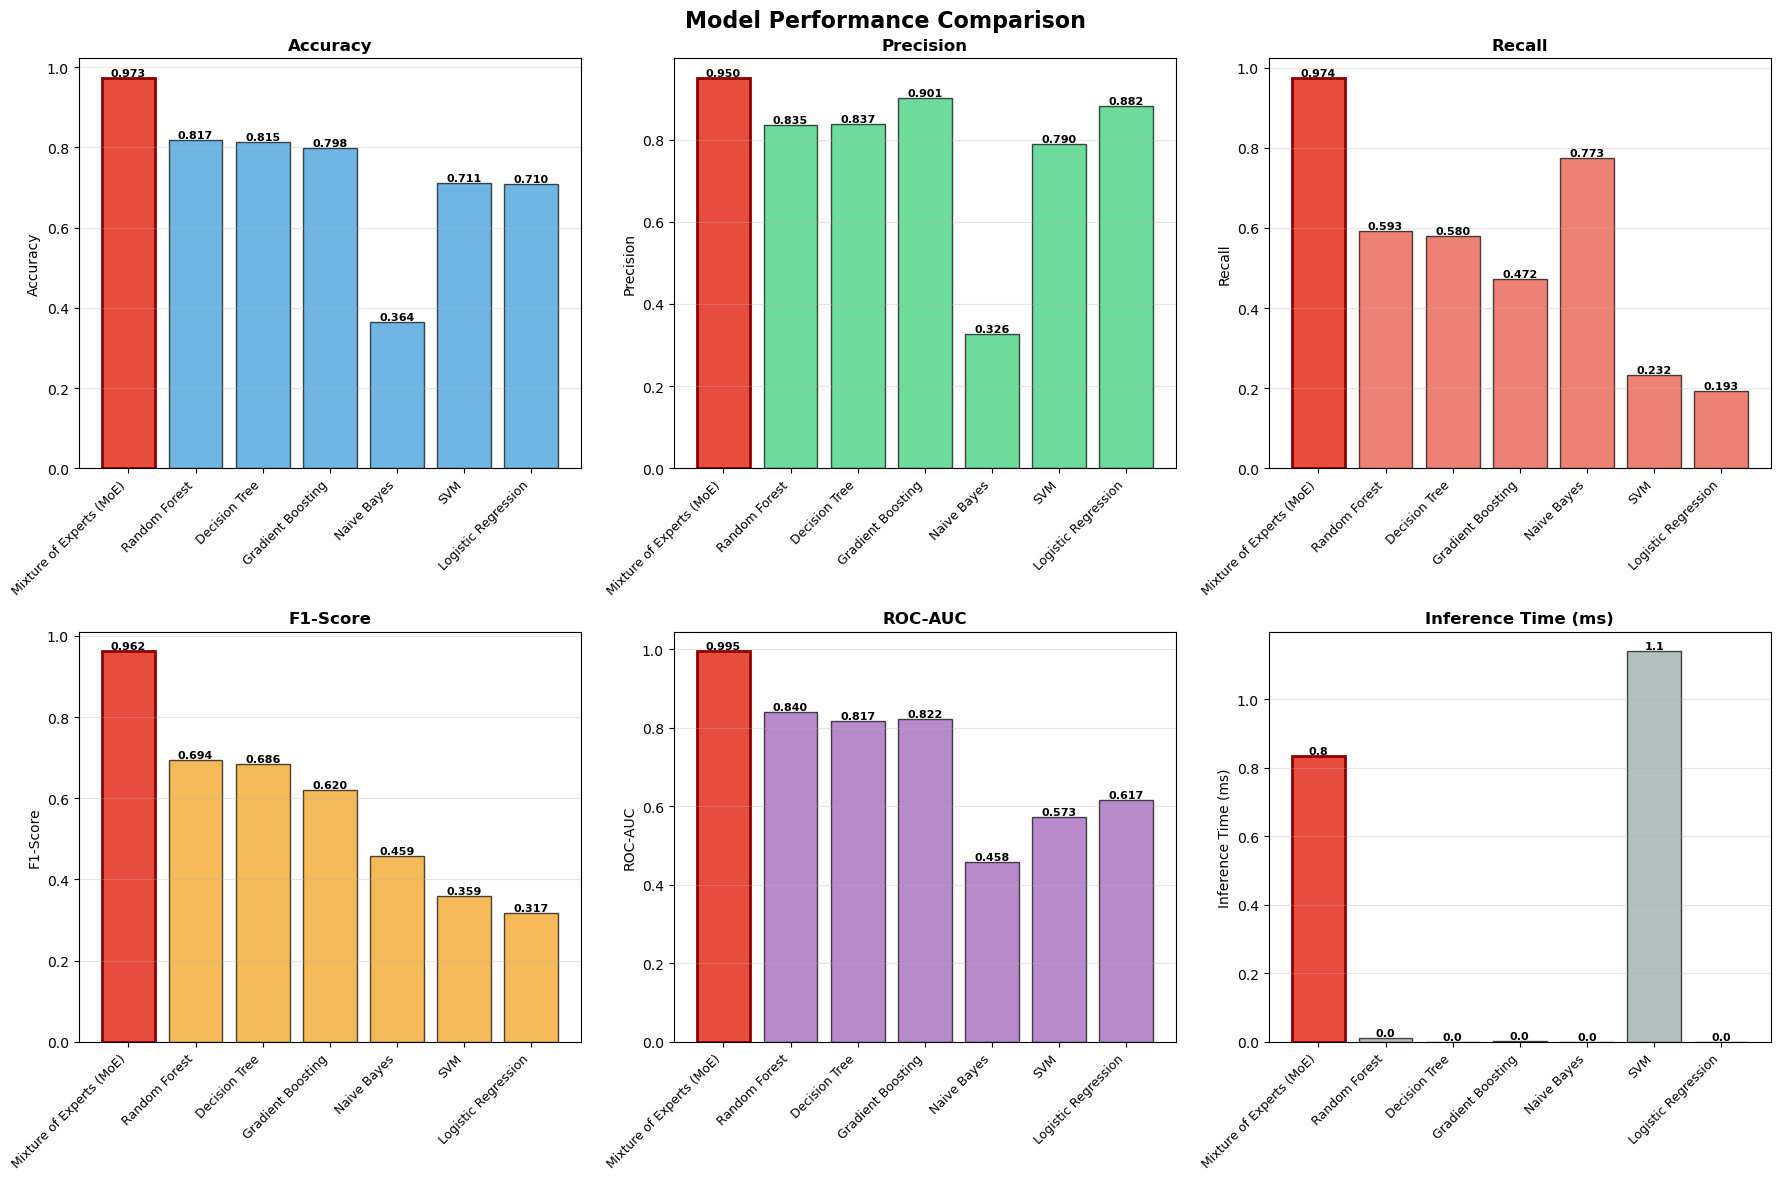

✓ Saved roc_curves.png


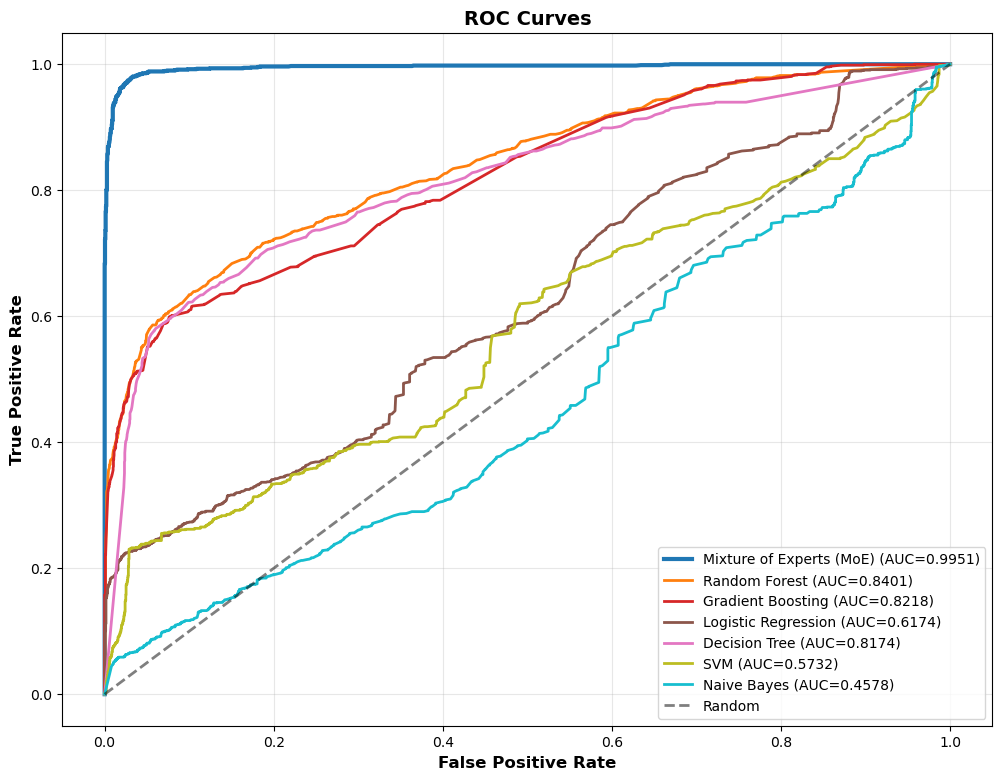

✓ Saved f1_ranking.png


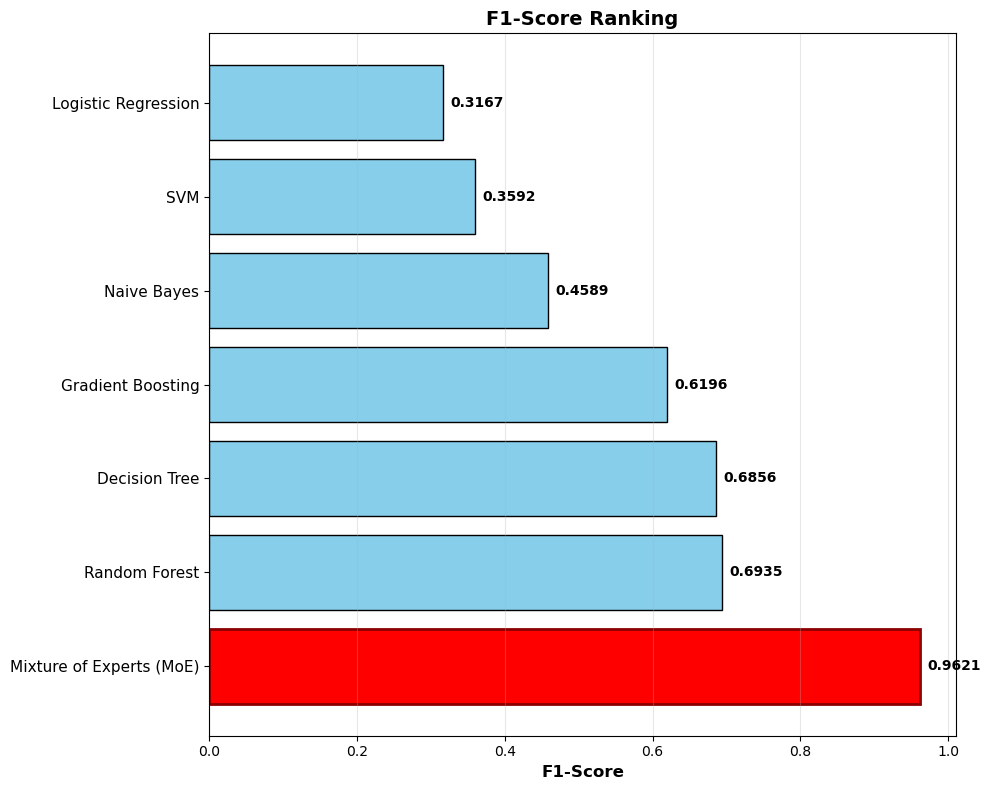


 Saving results...
✓ All results saved

 ANALYSIS COMPLETE - SUMMARY

 MoE Ranking: #1 out of 7 models

 MoE Final Results:
   F1-Score:   0.9621
   Accuracy:   0.9732
   Precision:  0.9503
   Recall:     0.9742
   ROC-AUC:    0.9951
   Speed:      0.83 ms/sample
   Throughput: 1200.7 samples/sec

 Top 3 Models:
   1. Mixture of Experts (MoE)
      F1=0.9621 | Acc=0.9732 | Time=0.8ms
   2. Random Forest
      F1=0.6935 | Acc=0.8173 | Time=0.0ms
   3. Decision Tree
      F1=0.6856 | Acc=0.8145 | Time=0.0ms

 Files Saved:
    comparative_results.csv
    moe_predictions.csv
    analysis_summary.txt
    performance_comparison.png
    roc_curves.png
    f1_ranking.png

 Speed Comparison:
   Model                     Avg Time (ms)   Throughput (samples/s)
   ------------------------------------------------------------
    Mixture of Experts (MoE) 0.83            1200.7
      Random Forest           0.01            90494.4
      Decision Tree           0.00            3990774.5
      Gradien

In [4]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import joblib
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import csr_matrix
import re
import time
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import seaborn as sns
from tqdm import tqdm

# Enable inline plotting for Jupyter
%matplotlib inline
plt.style.use('default')

# ============================================================================
# CONFIGURATION SECTION
# ============================================================================

CONFIG = {
    'INITIAL_SAMPLE_SIZE': 20000,  # Total samples to load
    'TEST_SAMPLE_SIZE': None,       # None = all data, or set to 500, 1000, etc.
    'BATCH_SIZE': 32,               # MoE batch size (32 optimal for most GPUs)
    'AUTO_RUN_CV': False,           # Auto cross-validation
    'RANDOM_STATE': 42,
}

# Model paths
PATHS = {
    'URL_MODEL': r"C:\Users\angelo\Downloads\THESIS\URL_Expert-20251210T060216Z-1-001\URL_Expert\Notebook and Model\url_expert_1.pkl",
    'TEXT_MODEL': r"C:\Users\angelo\Downloads\THESIS\distilbert_phishing_model",
    'GATING_NETWORK': 'gating_network.pth',
    'URL_DATASET': r"C:\Users\angelo\Downloads\THESIS\Dataset_5971\url_dataset_combined_1.csv",
    'TEXT_DATASET': r"C:\Users\angelo\Downloads\THESIS\Dataset_5971\Dataset_100k.csv"
}

# ============================================================================
# GATING NETWORK
# ============================================================================

class GatingNetwork(nn.Module):
    """Gating Network for MoE"""
    def __init__(self, input_size=8, hidden_size=64, num_experts=2):
        super(GatingNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_experts)
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return self.softmax(x)

# ============================================================================
# OPTIMIZED MOE PREDICTOR WITH BATCHING
# ============================================================================

class OptimizedMoEPredictor:
    """
    Optimized MoE predictor with batching, GPU support, and accurate timing
    """
    def __init__(self, url_model_path, text_model_path, gating_network_path, 
                 batch_size=32, device=None):
        self.batch_size = batch_size
        
        # Auto-detect device
        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
        
        print(f"🚀 Using device: {self.device}")
        
        # Load URL Expert
        self.url_expert = joblib.load(url_model_path)
        print("✓ URL Expert loaded")
        
        # Load Text Expert and move to device
        self.tokenizer = AutoTokenizer.from_pretrained(text_model_path)
        self.text_expert = AutoModelForSequenceClassification.from_pretrained(text_model_path)
        self.text_expert.to(self.device)
        self.text_expert.eval()
        print(f"✓ Text Expert loaded on {self.device}")
        
        # Load Gating Network and move to device
        self.gating_net = GatingNetwork(input_size=8, hidden_size=64, num_experts=2)
        self.gating_net.load_state_dict(torch.load(gating_network_path))
        self.gating_net.to(self.device)
        self.gating_net.eval()
        print(f"✓ Gating Network loaded on {self.device}")
        
        # Phrase dictionary
        self.phrase_dict = {
            'urgent': 0.3, 'verify account': 0.5, 'suspended': 0.4, 'click here': 0.3,
            'confirm your': 0.4, 'congratulations': 0.3, 'winner': 0.4, 'limited time': 0.3,
            'act now': 0.3, 'security alert': 0.5, 'claim': 0.3, 'prize': 0.3, 
            'free': 0.2, 'bonus': 0.2,
        }
    
    def preprocess_text(self, text):
        if pd.isna(text) or text == "":
            return ""
        text = re.sub(r'http\S+', '', text)
        return re.sub(r'\s+', ' ', text).strip()
    
    def calculate_phrase_score(self, text):
        if not text:
            return 0.0
        text_lower = text.lower()
        return min(sum(weight for phrase, weight in self.phrase_dict.items() 
                      if phrase in text_lower), 1.0)
    
    def extract_gating_features(self, texts, urls):
        features = []
        for text, url in zip(texts, urls):
            text = str(text) if pd.notna(text) else ""
            url = str(url) if pd.notna(url) else ""
            
            phrase_score = self.calculate_phrase_score(text)
            url_present = 1 if (url and url.strip()) else 0
            message_length = len(text.split()) if text else 0
            emoji_count = len(re.findall(r'[^\w\s,]', text)) if text else 0
            hashtag_count = text.count('#') if text else 0
            url_count = len(re.findall(r'http\S+', text)) if text else 0
            capital_ratio = sum(1 for c in text if c.isupper()) / max(len(text), 1) if text else 0.0
            
            features.append([url_present, phrase_score, message_length, emoji_count, 
                           hashtag_count, url_count, capital_ratio, 0.0])
        
        return np.array(features, dtype=np.float32)
    
    def predict_url_batch(self, urls):
        valid_urls = []
        url_indices = []
        
        for idx, url in enumerate(urls):
            url = str(url) if pd.notna(url) else ""
            if url and url.strip():
                valid_urls.append(url)
                url_indices.append(idx)
        
        probs = np.full((len(urls), 2), 0.5)
        
        if valid_urls:
            try:
                url_probs = self.url_expert.predict_proba(pd.DataFrame({'url': valid_urls}))
                probs[url_indices] = url_probs
            except:
                pass
        
        return probs
    
    def predict_text_batch(self, texts):
        processed_texts = [self.preprocess_text(str(text) if pd.notna(text) else "") 
                          for text in texts]
        
        valid_texts = []
        text_indices = []
        
        for idx, text in enumerate(processed_texts):
            if text and text.strip():
                valid_texts.append(text)
                text_indices.append(idx)
        
        probs = np.full((len(texts), 2), 0.5)
        
        if valid_texts:
            try:
                inputs = self.tokenizer(
                    valid_texts, 
                    return_tensors='pt', 
                    padding=True, 
                    truncation=True, 
                    max_length=128
                )
                
                inputs = {k: v.to(self.device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = self.text_expert(**inputs)
                    text_probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
                
                probs[text_indices] = text_probs
            except Exception as e:
                print(f"Warning: Text prediction failed: {e}")
        
        return probs
    
    def predict_batch(self, texts, urls):
        url_probs = self.predict_url_batch(urls)
        text_probs = self.predict_text_batch(texts)
        gating_features = self.extract_gating_features(texts, urls)
        
        with torch.no_grad():
            gating_input = torch.FloatTensor(gating_features).to(self.device)
            expert_weights = self.gating_net(gating_input).cpu().numpy()
        
        url_contribution = expert_weights[:, 0:1] * url_probs
        text_contribution = expert_weights[:, 1:2] * text_probs
        final_probs = url_contribution + text_contribution
        
        predictions = (final_probs[:, 1] > 0.5).astype(int)
        
        return {
            'predictions': predictions,
            'phishing_probabilities': final_probs[:, 1] * 100,
            'url_weights': expert_weights[:, 0] * 100,
            'text_weights': expert_weights[:, 1] * 100,
        }
    
    def predict_dataset(self, X_test, y_test=None, show_progress=True):
        """FIXED: Accurate inference time tracking"""
        n_samples = len(X_test)
        n_batches = (n_samples + self.batch_size - 1) // self.batch_size
        
        all_predictions = []
        all_phishing_probs = []
        all_url_weights = []
        all_text_weights = []
        
        # Warm-up run to avoid cold-start timing issues
        if n_samples > 0:
            warmup_texts = X_test.iloc[:min(2, n_samples)]['text'].tolist()
            warmup_urls = X_test.iloc[:min(2, n_samples)]['url'].tolist()
            _ = self.predict_batch(warmup_texts, warmup_urls)
        
        # ACCURATE TIMING: Only measure actual inference
        start_time = time.time()
        
        iterator = tqdm(range(n_batches), desc="🚀 MoE Inference") if show_progress else range(n_batches)
        
        for batch_idx in iterator:
            start_idx = batch_idx * self.batch_size
            end_idx = min(start_idx + self.batch_size, n_samples)
            
            batch_texts = X_test.iloc[start_idx:end_idx]['text'].tolist()
            batch_urls = X_test.iloc[start_idx:end_idx]['url'].tolist()
            
            batch_results = self.predict_batch(batch_texts, batch_urls)
            
            all_predictions.extend(batch_results['predictions'])
            all_phishing_probs.extend(batch_results['phishing_probabilities'])
            all_url_weights.extend(batch_results['url_weights'])
            all_text_weights.extend(batch_results['text_weights'])
        
        total_time = time.time() - start_time
        
        results = {
            'predictions': np.array(all_predictions),
            'phishing_probabilities': np.array(all_phishing_probs),
            'url_weights': np.array(all_url_weights),
            'text_weights': np.array(all_text_weights),
            'inference_time': total_time,
            'avg_time_ms': (total_time / n_samples) * 1000,
            'samples_per_second': n_samples / total_time if total_time > 0 else 0
        }
        
        if y_test is not None:
            y_true = y_test.values if hasattr(y_test, 'values') else y_test
            
            results.update({
                'model_name': 'Mixture of Experts (MoE)',
                'accuracy': accuracy_score(y_true, results['predictions']),
                'precision': precision_score(y_true, results['predictions'], zero_division=0),
                'recall': recall_score(y_true, results['predictions'], zero_division=0),
                'f1_score': f1_score(y_true, results['predictions'], zero_division=0),
                'roc_auc': roc_auc_score(y_true, results['phishing_probabilities'] / 100),
                'confusion_matrix': confusion_matrix(y_true, results['predictions']),
                'y_true': y_true,
                'samples_tested': len(y_true)
            })
        
        return results

# ============================================================================
# DATASET LOADING
# ============================================================================

def load_datasets_with_robust_processing(url_path, text_path, sample_size=20000):
    print(f"Loading URL dataset from: {url_path}")
    print(f"Loading text dataset from: {text_path}")
    
    # Load URL dataset
    try:
        df_url = pd.read_csv(url_path)
        print(f"✓ URL dataset loaded: {len(df_url)} rows")
    except Exception as e:
        print(f"✗ Error loading URL dataset: {e}")
        raise
    
    # Handle columns
    if 'url' in df_url.columns or 'URL' in df_url.columns:
        url_col = 'url' if 'url' in df_url.columns else 'URL'
        if 'label' in df_url.columns:
            df_url = df_url[[url_col, 'label']].copy()
            df_url.rename(columns={url_col: 'url'}, inplace=True)
        elif 'phishing' in df_url.columns:
            df_url = df_url[[url_col, 'phishing']].copy()
            df_url.rename(columns={url_col: 'url', 'phishing': 'label'}, inplace=True)
    
    df_url['text'] = ""
    
    # Load text dataset
    df_text = None
    encodings_to_try = ['utf-8', 'latin-1', 'ISO-8859-1', 'cp1252']
    
    for encoding in encodings_to_try:
        try:
            df_text = pd.read_csv(text_path, encoding=encoding, on_bad_lines='skip')
            print(f"✓ Text dataset loaded with {encoding}: {len(df_text)} rows")
            break
        except:
            continue
    
    if df_text is None:
        raise ValueError("Could not load text dataset")
    
    # Handle text dataset columns
    text_col = None
    label_col = None
    
    for col in df_text.columns:
        if 'text' in col.lower() or 'message' in col.lower():
            text_col = col
        if 'label' in col.lower() or 'class' in col.lower():
            label_col = col
    
    if text_col and label_col:
        df_text = df_text[[text_col, label_col]].copy()
        df_text.rename(columns={text_col: 'text', label_col: 'label'}, inplace=True)
    else:
        df_text = df_text.iloc[:, :2].copy()
        df_text.columns = ['text', 'label']
    
    df_text['url'] = ""
    
    # Combine
    df_combined = pd.concat([df_url, df_text], ignore_index=True)
    
    # Clean labels
    if df_combined['label'].dtype == object:
        df_combined['label'] = df_combined['label'].map({
            'safe': 0, 'phishing': 1, '0': 0, '1': 1, 
            'benign': 0, 'malicious': 1, 'legitimate': 0
        })
    
    df_combined['label'] = pd.to_numeric(df_combined['label'], errors='coerce').fillna(0).astype(int)
    df_combined = df_combined[~((df_combined['text'].isna() | (df_combined['text'] == '')) & 
                               (df_combined['url'].isna() | (df_combined['url'] == '')))]
    
    print(f"✓ Combined dataset: {len(df_combined)} samples")
    print(f"✓ Label distribution:\n{df_combined['label'].value_counts()}")
    
    # Sample if needed
    if sample_size and len(df_combined) > sample_size:
        df_combined = df_combined.sample(n=sample_size, random_state=42)
        print(f"✓ Sampled to {len(df_combined)} samples")
    
    # Split
    X = df_combined[['text', 'url']]
    y = df_combined['label']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    print(f"✓ Training: {len(X_train)}, Test: {len(X_test)}")
    
    return df_combined, X_train, X_test, y_train, y_test

# ============================================================================
# BASELINE MODELS
# ============================================================================

def extract_features(df):
    """Extract features for baseline models"""
    print("Extracting features...")
    features = []
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Features"):
        text = str(row['text']) if pd.notna(row['text']) else ""
        url = str(row['url']) if pd.notna(row['url']) else ""
        
        # Text features
        text_len = len(text)
        word_count = len(text.split())
        exclamation = text.count('!')
        question = text.count('?')
        upper_ratio = sum(1 for c in text if c.isupper()) / max(len(text), 1)
        
        # Phishing indicators
        indicators = ['urgent', 'click', 'verify', 'prize', 'winner', 
                     'suspended', 'security', 'alert', 'confirm', 'account']
        indicator_counts = [int(ind in text.lower()) for ind in indicators]
        
        # URL features
        url_present = int(bool(url))
        url_len = len(url) if url else 0
        url_dots = url.count('.') if url else 0
        url_special = sum(url.count(c) for c in ['=', '?', '&', '%']) if url else 0
        
        feature_vector = [text_len, word_count, exclamation, question, upper_ratio]
        feature_vector.extend(indicator_counts)
        feature_vector.extend([url_present, url_len, url_dots, url_special])
        
        features.append(feature_vector)
    
    return np.array(features)


def train_and_test_baseline_models(X_train, y_train, X_test, y_test):
    """FIXED: Accurate inference time tracking for baselines"""
    print("\n" + "=" * 70)
    print("Training baseline models...")
    print("=" * 70)
    
    X_train_features = extract_features(X_train)
    X_test_features = extract_features(X_test)
    
    algorithms = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'Naive Bayes': MultinomialNB()
    }
    
    results = {}
    
    for name, model in tqdm(algorithms.items(), desc="Training"):
        try:
            # Training
            model.fit(X_train_features, y_train)
            
            # ACCURATE TIMING: Warm-up + timed inference
            _ = model.predict(X_test_features[:2])  # Warm-up
            
            test_start = time.time()
            if hasattr(model, 'predict_proba'):
                y_pred_proba = model.predict_proba(X_test_features)[:, 1]
                y_pred = (y_pred_proba > 0.5).astype(int)
            else:
                y_pred = model.predict(X_test_features)
                y_pred_proba = y_pred
            test_time = time.time() - test_start
            
            results[name] = {
                'model_name': name,
                'accuracy': accuracy_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred, zero_division=0),
                'recall': recall_score(y_test, y_pred, zero_division=0),
                'f1_score': f1_score(y_test, y_pred, zero_division=0),
                'roc_auc': roc_auc_score(y_test, y_pred_proba) if hasattr(model, 'predict_proba') else 0.0,
                'inference_time': test_time,
                'avg_time_ms': (test_time / len(X_test)) * 1000,
                'samples_per_second': len(X_test) / test_time if test_time > 0 else 0,
                'confusion_matrix': confusion_matrix(y_test, y_pred),
                'predictions': y_pred,
                'probabilities': y_pred_proba,
                'y_true': y_test.values,
                'samples_tested': len(y_test)
            }
            
        except Exception as e:
            print(f"\nWarning: {name} failed: {str(e)[:100]}")
            continue
    
    return results

# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_comparison_results(moe_results, baseline_results):
    """Create comprehensive comparison plots"""
    print("\n📊 Generating visualizations...")
    
    all_results = [moe_results] + list(baseline_results.values())
    comparison_df = pd.DataFrame(all_results)
    comparison_df = comparison_df.sort_values('f1_score', ascending=False)
    
    # 1. Performance Metrics
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    
    metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'avg_time_ms']
    titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Inference Time (ms)']
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#95a5a6']
    
    for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
        ax = axes[idx // 3, idx % 3]
        bars = ax.bar(range(len(comparison_df)), comparison_df[metric], 
                     color=color, alpha=0.7, edgecolor='black')
        
        # Highlight MoE
        for i, bar in enumerate(bars):
            if 'MoE' in comparison_df.iloc[i]['model_name']:
                bar.set_color('#e74c3c')
                bar.set_alpha(1.0)
                bar.set_edgecolor('darkred')
                bar.set_linewidth(2)
        
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_ylabel(title, fontsize=10)
        ax.set_xticks(range(len(comparison_df)))
        ax.set_xticklabels(comparison_df['model_name'], rotation=45, ha='right', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Value labels
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}' if metric != 'avg_time_ms' else f'{height:.1f}',
                   ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Saved performance_comparison.png")
    plt.show()
    
    # 2. ROC Curves
    plt.figure(figsize=(12, 9))
    colors_roc = plt.cm.tab10(np.linspace(0, 1, len(all_results)))
    
    for idx, result in enumerate(all_results):
        if 'phishing_probabilities' in result:
            probs = np.array(result['phishing_probabilities']) / 100
            y_true = result['y_true']
        elif result.get('probabilities') is not None:
            probs = result['probabilities']
            y_true = result['y_true']
        else:
            continue
        
        fpr, tpr, _ = roc_curve(y_true, probs)
        roc_auc = result.get('roc_auc', roc_auc_score(y_true, probs))
        
        linewidth = 3 if 'MoE' in result['model_name'] else 2
        plt.plot(fpr, tpr, label=f"{result['model_name']} (AUC={roc_auc:.4f})",
                linewidth=linewidth, color=colors_roc[idx])
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2, alpha=0.5)
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title('ROC Curves', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
    print("✓ Saved roc_curves.png")
    plt.show()
    
    # 3. F1-Score Ranking
    plt.figure(figsize=(10, 8))
    bars = plt.barh(range(len(comparison_df)), comparison_df['f1_score'], 
                   color='skyblue', edgecolor='black')
    
    for i, (_, row) in enumerate(comparison_df.iterrows()):
        if 'MoE' in row['model_name']:
            bars[i].set_color('red')
            bars[i].set_edgecolor('darkred')
            bars[i].set_linewidth(2)
    
    plt.yticks(range(len(comparison_df)), comparison_df['model_name'], fontsize=11)
    plt.xlabel('F1-Score', fontsize=12, fontweight='bold')
    plt.title('F1-Score Ranking', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    
    for i, v in enumerate(comparison_df['f1_score']):
        plt.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('f1_ranking.png', dpi=300, bbox_inches='tight')
    print("✓ Saved f1_ranking.png")
    plt.show()
    
    plt.close('all')
    return comparison_df

# ============================================================================
# SAVE RESULTS
# ============================================================================

def save_results(moe_results, baseline_results, comparison_df, X_test):
    """Save all results to files"""
    print("\n Saving results...")
    
    # Comparison table
    comparison_df.to_csv('comparative_results.csv', index=False)
    
    # MoE predictions
    moe_details = pd.DataFrame({
        'text': X_test['text'].values[:len(moe_results['predictions'])],
        'url': X_test['url'].values[:len(moe_results['predictions'])],
        'true_label': moe_results['y_true'],
        'predicted_label': moe_results['predictions'],
        'phishing_prob': moe_results['phishing_probabilities'],
        'url_weight': moe_results['url_weights'],
        'text_weight': moe_results['text_weights']
    })
    moe_details.to_csv('moe_predictions.csv', index=False)
    
    # Summary report
    with open('analysis_summary.txt', 'w') as f:
        f.write("=" * 70 + "\n")
        f.write("PHISHING DETECTION COMPARATIVE ANALYSIS\n")
        f.write("=" * 70 + "\n\n")
        
        f.write(f"Test Set Size: {len(moe_results['y_true'])} samples\n")
        f.write(f"Phishing: {(moe_results['y_true'] == 1).sum()}\n")
        f.write(f"Safe: {(moe_results['y_true'] == 0).sum()}\n\n")
        
        f.write("=" * 70 + "\n")
        f.write("PERFORMANCE RANKING (by F1-Score)\n")
        f.write("=" * 70 + "\n\n")
        
        for i, (_, row) in enumerate(comparison_df.iterrows(), 1):
            f.write(f"{i}. {row['model_name']}:\n")
            f.write(f"   Accuracy:   {row['accuracy']:.4f}\n")
            f.write(f"   Precision:  {row['precision']:.4f}\n")
            f.write(f"   Recall:     {row['recall']:.4f}\n")
            f.write(f"   F1-Score:   {row['f1_score']:.4f}\n")
            f.write(f"   ROC-AUC:    {row['roc_auc']:.4f}\n")
            f.write(f"   Avg Time:   {row['avg_time_ms']:.2f} ms\n")
            f.write(f"   Throughput: {row['samples_per_second']:.1f} samples/sec\n\n")
    
    print("✓ All results saved")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    try:
    
        
        print(f"\n⚙️  Configuration:")
        print(f"   Initial samples: {CONFIG['INITIAL_SAMPLE_SIZE']}")
        print(f"   Test size: {'ALL' if CONFIG['TEST_SAMPLE_SIZE'] is None else CONFIG['TEST_SAMPLE_SIZE']}")
        print(f"   Batch size: {CONFIG['BATCH_SIZE']}")
        print(f"   Random state: {CONFIG['RANDOM_STATE']}")
        
        # ===== LOAD DATASETS =====
        print("\n" + "=" * 70)
        print("LOADING DATASETS")
        print("=" * 70)
        
        df_combined, X_train, X_test, y_train, y_test = load_datasets_with_robust_processing(
            PATHS['URL_DATASET'], 
            PATHS['TEXT_DATASET'], 
            sample_size=CONFIG['INITIAL_SAMPLE_SIZE']
        )
        
        # ===== APPLY TEST SIZE LIMIT (EQUAL FOR ALL MODELS) =====
        if CONFIG['TEST_SAMPLE_SIZE'] and CONFIG['TEST_SAMPLE_SIZE'] < len(X_test):
            print(f"\n Applying equal test size limit: {CONFIG['TEST_SAMPLE_SIZE']} samples")
            indices = np.random.RandomState(CONFIG['RANDOM_STATE']).choice(
                len(X_test), CONFIG['TEST_SAMPLE_SIZE'], replace=False
            )
            X_test = X_test.iloc[indices].reset_index(drop=True)
            y_test = y_test.iloc[indices].reset_index(drop=True)
            print(f"✓ All models will test on same {len(X_test)} samples")
        else:
            print(f"\n✓ All models will test on full test set: {len(X_test)} samples")
        
        # ===== TEST MOE SYSTEM =====
        print("\n" + "=" * 70)
        print(" TESTING MOE SYSTEM (OPTIMIZED)")
        print("=" * 70)
        
        predictor = OptimizedMoEPredictor(
            url_model_path=PATHS['URL_MODEL'],
            text_model_path=PATHS['TEXT_MODEL'],
            gating_network_path=PATHS['GATING_NETWORK'],
            batch_size=CONFIG['BATCH_SIZE'],
            device='cuda' if torch.cuda.is_available() else 'cpu'
        )
        
        moe_results = predictor.predict_dataset(X_test, y_test, show_progress=True)
        
        print(f"\n⚡ MoE Performance:")
        print(f"   Samples tested: {moe_results['samples_tested']}")
        print(f"   Total time: {moe_results['inference_time']:.3f}s")
        print(f"   Avg time: {moe_results['avg_time_ms']:.2f} ms/sample")
        print(f"   Throughput: {moe_results['samples_per_second']:.1f} samples/sec")
        print(f"   Accuracy: {moe_results['accuracy']:.4f}")
        print(f"   F1-Score: {moe_results['f1_score']:.4f}")
        
        # ===== TEST BASELINE MODELS =====
        baseline_results = train_and_test_baseline_models(X_train, y_train, X_test, y_test)
        
        print(f"\n✓ Tested {len(baseline_results)} baseline models")
        
        # ===== VISUALIZATION & RESULTS =====
        print("\n" + "=" * 70)
        print("GENERATING RESULTS")
        print("=" * 70)
        
        comparison_df = plot_comparison_results(moe_results, baseline_results)
        save_results(moe_results, baseline_results, comparison_df, X_test)
        
        # ===== FINAL SUMMARY =====
        print("\n" + "=" * 70)
        print(" ANALYSIS COMPLETE - SUMMARY")
        print("=" * 70)
        
        moe_rank = comparison_df[comparison_df['model_name'].str.contains('MoE')].index[0] + 1
        print(f"\n MoE Ranking: #{moe_rank} out of {len(comparison_df)} models")
        
        moe_row = comparison_df[comparison_df['model_name'].str.contains('MoE')].iloc[0]
        print(f"\n MoE Final Results:")
        print(f"   F1-Score:   {moe_row['f1_score']:.4f}")
        print(f"   Accuracy:   {moe_row['accuracy']:.4f}")
        print(f"   Precision:  {moe_row['precision']:.4f}")
        print(f"   Recall:     {moe_row['recall']:.4f}")
        print(f"   ROC-AUC:    {moe_row['roc_auc']:.4f}")
        print(f"   Speed:      {moe_row['avg_time_ms']:.2f} ms/sample")
        print(f"   Throughput: {moe_row['samples_per_second']:.1f} samples/sec")
        
        print(f"\n Top 3 Models:")
        for i in range(min(3, len(comparison_df))):
            row = comparison_df.iloc[i]
            print(f"   {i+1}. {row['model_name']}")
            print(f"      F1={row['f1_score']:.4f} | Acc={row['accuracy']:.4f} | Time={row['avg_time_ms']:.1f}ms")
        
        print(f"\n Files Saved:")
        print(f"    comparative_results.csv")
        print(f"    moe_predictions.csv")
        print(f"    analysis_summary.txt")
        print(f"    performance_comparison.png")
        print(f"    roc_curves.png")
        print(f"    f1_ranking.png")
        
        # Inference speed summary
        print(f"\n Speed Comparison:")
        print(f"   {'Model':<25} {'Avg Time (ms)':<15} {'Throughput (samples/s)'}")
        print(f"   {'-'*60}")
        for _, row in comparison_df.iterrows():
            model_mark = "" if 'MoE' in row['model_name'] else "  "
            print(f"   {model_mark} {row['model_name']:<23} {row['avg_time_ms']:<15.2f} {row['samples_per_second']:<.1f}")
        
        print("\n" + "=" * 70)
        print(" ANALYSIS SUCCESSFULLY COMPLETED!")
        print("=" * 70)
        
    except Exception as e:
        print(f"\n Error: {str(e)}")
        import traceback
        traceback.print_exc()